# Assignment 5 - Idea Research: Weekly Mean Reversion in Swiss Equities

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch,
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch,
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch,
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Executive Summary

This notebook develops, tests, and freezes the investment idea used by the companion out-of-sample backtest. The economic starting point is **weekly mean reversion**: unusually weak stocks may rebound after temporary price pressure. A cross-sectional Ridge regression combines this reversal signal with risk, liquidity, value, quality, and momentum information to forecast each stock's next-week return rank.

The research design is deliberately separated from the final evaluation. Ridge regularization is selected using data ending in 2014. Walk-forward predictions from 2010-2019 are then used to test tradability, select EWMA turnover-control parameters, and calibrate Black-Litterman views. Data from 2020 onward are not used for any decision in this notebook.

### Research Outcome At A Glance

| Decision | Frozen development result |
| --- | --- |
| Main economic feature | Volatility-scaled weekly reversal |
| Ridge target | Next-week cross-sectional return rank |
| Ridge training window | 156 weeks |
| Ridge refit schedule | Every 13 weeks |
| Selected Ridge penalty | $\alpha=1{,}000$ |
| Continuous EWMA speed | $\lambda=0.35$ |
| Top-tail EWMA speed | $\lambda=0.10$ |
| Continuous BL weekly active view | $0.248\%$ |
| Top-tail BL weekly active view | $0.334\%$ |

## Table Of Contents

1. [Research Objective And Roadmap](#research-objective-and-roadmap)
2. [Economic Hypothesis And No-Lookahead Design](#economic-hypothesis-and-no-lookahead-design)
3. [Data, Returns, And Candidate Reversal Signals](#data-returns-and-candidate-reversal-signals)
4. [Baseline Predictive Diagnostics](#baseline-predictive-diagnostics)
5. [Ridge Regression Signal Model](#ridge-regression-signal-model)
6. [Walk-Forward Training And Hyperparameter Selection](#walk-forward-training-and-hyperparameter-selection)
7. [Portfolio Construction And Economic Feasibility](#portfolio-construction-and-economic-feasibility)
8. [Tradability Filters And Baseline Comparison](#tradability-filters-and-baseline-comparison)
9. [Transaction Costs And Long-Short Attribution](#transaction-costs-and-long-short-attribution)
10. [EWMA Turnover Control](#ewma-turnover-control)
11. [Black-Litterman Calibration](#black-litterman-calibration)
12. [Frozen Decisions For The OOS Backtest](#frozen-decisions-for-the-oos-backtest)


## Research Objective And Roadmap

The objective is to determine whether a short-horizon reversal effect can support a realistic Swiss-equity strategy after accounting for data timing, liquidity, turnover, and transaction costs. The notebook answers four increasingly demanding questions:

1. **Predictive content:** do recent losers outperform recent winners over the following week?
2. **Model enhancement:** can Ridge regression improve the ranking by combining reversal with complementary characteristics?
3. **Implementation feasibility:** does the signal survive tradability filters and realistic costs?
4. **Portfolio calibration:** which EWMA speeds and Black-Litterman views should be frozen before final testing?

The research sequence is:

    Economic hypothesis and data timing
    -> candidate reversal signals
    -> baseline rank diagnostics
    -> Ridge feature construction
    -> walk-forward alpha selection
    -> Ridge versus reversal comparison
    -> tradable portfolio tests
    -> cost and leg attribution
    -> EWMA calibration
    -> Black-Litterman calibration
    -> frozen 2020+ backtest specification

The key distinction is between **signal quality** and **strategy quality**. A statistically predictive score is useful only if its portfolio payoff remains economically meaningful after filtering and trading frictions.


## Economic Hypothesis And No-Lookahead Design

Short-term reversal may arise when liquidity shocks, non-informational order flow, or temporary investor overreaction push prices away from short-run equilibrium. If this pressure unwinds, stocks with unusually poor performance during week $t$ should rank more highly in week $t+1$.

The baseline hypothesis is

$$
H_1:\quad
\rho_{S,t}\left(s_{i,t},R^W_{i,t+1}\right)>0,
$$

where $s_{i,t}$ is a formation-time score and $\rho_{S,t}$ is the cross-sectional Spearman correlation in week $t$.

### Information-Timing Rules

| Research operation | Latest information permitted |
| --- | --- |
| Construct weekly features | End of completed week $t$ |
| Form the target | Realized return during week $t+1$ |
| Train Ridge at a refit date | Only targets fully realized before that refit |
| Select Ridge $\alpha$ | Walk-forward observations ending December 2014 |
| Select EWMA and BL parameters | Walk-forward development results from 2010-2019 |
| Evaluate final performance | Reserved for 2020+ in the companion notebook |

At each quarterly model refit, the most recent possible feature week is embargoed because its next-week target is not fully known. Ridge uses the preceding 156 eligible weeks and is refitted every 13 weeks. Between refits, the most recently estimated coefficients are reused for weekly inference.

This separation prevents the model, smoothing parameters, and optimizer views from being selected using final out-of-sample outcomes.


## Data, Returns, And Candidate Reversal Signals

The analysis uses:

- market_data.parquet for prices and daily traded monetary value;
- jkp_data.parquet for value, quality, and momentum characteristics;
- spi_index.csv for the Swiss Performance Index market return.

The market panel is cleaned only for missing security identifiers and duplicate security-date records. Missing prices are not forward-filled before return construction because doing so would create artificial zero returns, which are especially damaging in a short-horizon reversal study. Extreme daily returns are reported for data-quality awareness but are not silently removed.


### Daily And Weekly Returns

For closing price $P_{i,d}$, the daily return is

$$
r^D_{i,d}=\frac{P_{i,d}}{P_{i,d-1}}-1.
$$

Daily observations are compounded into Friday-labelled weekly returns:

$$
R^W_{i,t}
=
\prod_{d\in\mathcal{W}(t)}\left(1+r^D_{i,d}\right)-1.
$$

At least three valid daily observations are required for a weekly return. A score formed after the completed week $t$ is matched only with the subsequent weekly return:

$$
x_{i,t}\longrightarrow R^W_{i,t+1}.
$$

The last development formation date is retained only when its outcome also lies inside 2010-2019. This avoids allowing January 2020 returns to influence any research decision.


### Candidate Reversal Signals

All reversal variables follow the same sign convention: a higher score indicates larger recent underperformance and therefore a stronger rebound candidate.

#### Raw Weekly Reversal

$$
s^{raw}_{i,t}=-R^W_{i,t}.
$$

This is the most direct expression of the hypothesis, but it can mechanically favor highly volatile stocks.

#### Volatility-Scaled Reversal

$$
s^{vol}_{i,t}
=
-\frac{R^W_{i,t}}{\sigma^W_{i,t}},
\qquad
\sigma^W_{i,t}
=
\operatorname{Std}\left(R^W_{i,t-103},\ldots,R^W_{i,t}\right).
$$

Scaling by 104-week volatility asks whether the most recent move is unusually negative relative to the stock's own risk. This becomes the main economic feature and the transparent baseline strategy.

#### Market-Residual Volatility-Scaled Reversal

A one-day-lagged market beta is estimated as

$$
\widehat{\beta}_{i,d-1}
=
\frac{\operatorname{Cov}_{d-1}(r^D_i,r^{SPI})}
{\operatorname{Var}_{d-1}(r^{SPI})}.
$$

Residual daily returns are

$$
r^{res,D}_{i,d}
=
r^D_{i,d}
-\widehat{\beta}_{i,d-1}r^{SPI}_d,
$$

and the weekly residual score is

$$
s^{res}_{i,t}
=
-\frac{R^{res,W}_{i,t}}{\sigma^{res,W}_{i,t}}.
$$

This specification tests whether stock-specific underperformance predicts a rebound after broad market movement is removed.

The following configuration cell centralizes all dates, estimator windows, costs, screens, and output paths so the research choices remain auditable.


In [1]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import Ridge
from tqdm.auto import tqdm

pd.options.display.float_format = "{:,.4f}".format

# Locate shared inputs whether execution begins at the repository root or assignments/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml.transformers.panel.cross_sectional import (
    CrossSectionalWinsorize,
    CrossSectionalZScore,
)


In [2]:
@dataclass(frozen=True)
class ResearchConfig:
    """Frozen assumptions for development-stage signal and implementation research."""

    study_start_date: str = "2010-01-01"
    study_end_date: str = "2019-12-31"
    ridge_alpha_selection_end_date: str = "2014-12-31"
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3
    forecast_horizon_weeks: int = 1
    weeks_per_year: int = 52

    selected_signal_name: str = "Volatility-scaled reversal"
    vol_lookback_weeks: int = 104
    min_vol_weeks: int = 26
    beta_window_days: int = 252
    min_beta_days: int = 126
    beta_estimate_lag_days: int = 1

    ridge_training_window_weeks: int = 156
    ridge_retrain_every_weeks: int = 13
    # Broad logarithmic grid: the previous optimum was at the old upper boundary.
    ridge_alpha_grid: tuple[float, ...] = (
        0.01, 0.1, 1.0, 10.0, 100.0, 1_000.0, 10_000.0
    )

    minimum_cross_section_size: int = 30
    minimum_distinct_cross_section_values: int = 2
    newey_west_max_lags: int = 4
    hit_rate_null_probability: float = 0.50

    hml_tail_fraction: float = 0.10
    leg_gross_exposure: float = 0.50
    variable_transaction_cost: float = 0.002
    fixed_cost_annual: float = 0.01
    fixed_cost_leg_share: float = 0.50
    daily_return_alert: float = 0.50

    score_availability_lookback_days: int = 365
    liquidity_window_observations: int = 63
    minimum_median_daily_traded_value: float = 100_000
    liquidity_gap_window_observations: int = 365
    maximum_zero_liquidity_gap: int = 10
    weekday_upper_bound: int = 5
    terminal_rows_retained: int = 2

    ewma_lambda_start: float = 0.05
    ewma_lambda_stop: float = 1.00
    ewma_lambda_step: float = 0.05
    bl_omega_multiplier: float = 5.00

    calibration_path: Path = RESULTS_DIR / "mean_reversion_ridge_calibration.json"
    development_score_path: Path = RESULTS_DIR / "mean_reversion_ridge_development_scores.parquet"
    coefficient_path: Path = RESULTS_DIR / "mean_reversion_ridge_coefficients.parquet"


CONFIG = ResearchConfig()
STUDY_START = pd.Timestamp(CONFIG.study_start_date)
STUDY_END = pd.Timestamp(CONFIG.study_end_date)
CONFIG


ResearchConfig(study_start_date='2010-01-01', study_end_date='2019-12-31', ridge_alpha_selection_end_date='2014-12-31', weekly_resample_rule='W-FRI', weekly_min_days=3, forecast_horizon_weeks=1, weeks_per_year=52, selected_signal_name='Volatility-scaled reversal', vol_lookback_weeks=104, min_vol_weeks=26, beta_window_days=252, min_beta_days=126, beta_estimate_lag_days=1, ridge_training_window_weeks=156, ridge_retrain_every_weeks=13, ridge_alpha_grid=(0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0), minimum_cross_section_size=30, minimum_distinct_cross_section_values=2, newey_west_max_lags=4, hit_rate_null_probability=0.5, hml_tail_fraction=0.1, leg_gross_exposure=0.5, variable_transaction_cost=0.002, fixed_cost_annual=0.01, fixed_cost_leg_share=0.5, daily_return_alert=0.5, score_availability_lookback_days=365, liquidity_window_observations=63, minimum_median_daily_traded_value=100000, liquidity_gap_window_observations=365, maximum_zero_liquidity_gap=10, weekday_upper_bound=5, terminal_ro

### Data Preparation And Quality Checks

The next cells reshape the identified market panel into price and return matrices, load SPI returns, and report sample coverage. The data-quality summary is descriptive: it highlights missing observations and extreme returns without changing the primary sample.

This stage produces the daily inputs required for weekly returns, rolling volatility, market beta, liquidity measures, and the later point-in-time filters.


In [3]:
# Keep one identified record per security-date before reshaping the equity panel.
market_data_raw = pd.read_parquet(DATA_DIR / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]), level=date_level
)
missing_id = market_data_raw.index.get_level_values("id").isna()
identified = market_data_raw[~missing_id]
duplicate_rows = identified.index.duplicated(keep="last").sum()
market_data = identified[~identified.index.duplicated(keep="last")].sort_index()

prices = market_data["price"].unstack("id").sort_index()
daily_stock_returns = prices.pct_change(fill_method=None)
daily_return_values = daily_stock_returns.stack().rename("daily_return")

In [4]:
# SPI is required only to construct the market-residual candidate score.
daily_spi_returns = pd.read_csv(
    DATA_DIR / "spi_index.csv", index_col=0, parse_dates=True, date_format="%d/%m/%Y"
).squeeze("columns").sort_index().rename("SPI").reindex(daily_stock_returns.index)

data_summary = pd.DataFrame(
    {
        "First date": [prices.index.min()],
        "Last date": [prices.index.max()],
        "Securities": [prices.shape[1]],
        "Trading dates": [prices.shape[0]],
        "Missing price fraction": [prices.isna().to_numpy().mean()],
        "Rows without security id removed": [missing_id.sum()],
        "Duplicate security-date rows removed": [duplicate_rows],
        "Minimum daily return": [daily_return_values.min()],
        "Maximum daily return": [daily_return_values.max()],
        f"Absolute daily returns above {CONFIG.daily_return_alert:.0%}": [(daily_return_values.abs() > CONFIG.daily_return_alert).sum()],
    },
    index=["Swiss equity panel"],
)
display(data_summary)

,First date,Last date,Securities,Trading dates,Missing price fraction,Rows without security id removed,Duplicate security-date rows removed,Minimum daily return,Maximum daily return,Absolute daily returns above 50%
Swiss equity panel,1985-12-31,2024-04-30,313,9978,0.5547,43449,0,-0.9477,9.1818,153


### Formation-Time Signal Construction

Weekly returns, market returns, and trailing volatility are calculated before any predictive evaluation. The market beta used in residual reversal is shifted by one day, ensuring that the residual return for day $d$ never uses a beta estimate containing day $d$'s return.

The resulting signal panels are dated at formation week $t$. Forward weekly returns are created separately and are used only as labels or realized portfolio outcomes.


In [5]:
# Aggregate returns to the one-week signal and forecasting horizon.
weekly_returns = (
    (1 + daily_stock_returns).resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days) - 1
)
weekly_spi_returns = (
    (1 + daily_spi_returns).resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days) - 1
)
weekly_presence = (
    prices.notna().resample(CONFIG.weekly_resample_rule).last()
    .reindex_like(weekly_returns).fillna(False)
)
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()

In [6]:
# Use a lagged daily beta so residual scores contain no contemporaneous estimate.
rolling_beta = daily_stock_returns.rolling(
    CONFIG.beta_window_days, min_periods=CONFIG.min_beta_days
).cov(daily_spi_returns).divide(
    daily_spi_returns.rolling(CONFIG.beta_window_days, min_periods=CONFIG.min_beta_days).var(),
    axis=0,
).shift(CONFIG.beta_estimate_lag_days)
weekly_residual_returns = (
    (1 + daily_stock_returns - rolling_beta.multiply(daily_spi_returns, axis=0))
    .resample(CONFIG.weekly_resample_rule).prod(min_count=CONFIG.weekly_min_days) - 1
)
weekly_residual_volatility = weekly_residual_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()

candidate_scores = {
    "Raw reversal": (-weekly_returns).where(weekly_presence),
    "Volatility-scaled reversal": (-weekly_returns / weekly_volatility).where(weekly_presence),
    "Residual volatility-scaled reversal": (-weekly_residual_returns / weekly_residual_volatility).where(weekly_presence),
}
candidate_scores = {name: score.replace([np.inf, -np.inf], np.nan) for name, score in candidate_scores.items()}

In [7]:
# Shifted returns are ex-post evaluation targets, never formation-time filters.
forward_weekly_returns = weekly_returns.shift(-CONFIG.forecast_horizon_weeks)
weekly_dates = weekly_returns.index
formation_dates = weekly_dates[:-CONFIG.forecast_horizon_weeks]
outcome_dates = weekly_dates[CONFIG.forecast_horizon_weeks:]
research_formation_dates = formation_dates[
    (formation_dates >= STUDY_START)
    & (formation_dates <= STUDY_END)
    & (outcome_dates <= STUDY_END)
]

availability_summary = pd.DataFrame(
    {
        "Average available scores": [
            score.reindex(research_formation_dates).notna().sum(axis=1).mean()
            for score in candidate_scores.values()
        ],
        "Median available scores": [
            score.reindex(research_formation_dates).notna().sum(axis=1).median()
            for score in candidate_scores.values()
        ],
    },
    index=candidate_scores,
)
display(availability_summary.round(1))

,Average available scores,Median available scores
Raw reversal,184.5000,184.0000
Volatility-scaled reversal,182.7000,182.0000
Residual volatility-scaled reversal,181.0000,181.0000


## Baseline Predictive Diagnostics

Before fitting a machine-learning model, the three economically motivated reversal scores are evaluated without constructing portfolios.

For a weekly cross-section of $N_t$ stocks, scores and future returns are transformed to centered ranks:

$$
x_{i,t}
=
2\frac{\operatorname{Rank}_t(s_{i,t})-1}{N_t-1}-1,
\qquad
y_{i,t+1}
=
2\frac{\operatorname{Rank}_t(R^W_{i,t+1})-1}{N_t-1}-1.
$$

The weekly information coefficient is

$$
IC_t
=
\operatorname{Corr}_{\mathrm{Spearman}}\left(s_{i,t},R^W_{i,t+1}\right).
$$

The report includes:

- mean weekly IC with a four-lag Newey-West t-statistic;
- a pooled rank regression,

$$
y_{i,t+1}=\beta^{rank}x_{i,t}+\varepsilon_{i,t+1},
$$

with equal total weight per week and week-clustered standard errors;
- the cross-sectional directional hit rate relative to a 50% null;
- prediction coverage and pooled sample size.

These diagnostics measure ordering ability. They do not yet account for turnover, costs, or portfolio constraints.


In [8]:
import statsmodels.api as sm

def centered_rank(values: pd.Series) -> pd.Series:
    '''Map within-week average ranks to the strategy-relevant [-1, 1] scale.'''
    ranks = values.rank(method="average")
    return 2 * (ranks - 1) / (len(values) - 1) - 1


def newey_west_mean_test(values: pd.Series, null: float = 0.0) -> tuple[float, float]:
    '''Return the sample mean and HAC t-statistic relative to a stated null.'''
    valid = values.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    fit = sm.OLS(valid.to_numpy() - null, np.ones((len(valid), 1))).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": CONFIG.newey_west_max_lags},
    )
    return valid.mean(), float(fit.tvalues[0])

In [9]:
def score_vector_diagnostics(score: pd.DataFrame) -> dict:
    '''Measure one score's predictive content without constructing holdings.'''
    ic_by_week = {}
    hit_rate_by_week = {}
    rank_rows = []
    matched_counts = []

    # Evaluate each formation week separately so large cross-sections do not dominate time-series inference.
    for date in research_formation_dates:
        # Inner validity is imposed after score and next-week return are aligned by security identifier.
        cross_section = pd.concat(
            {"score": score.loc[date], "forward_return": forward_weekly_returns.loc[date]},
            axis=1,
        )
        cross_section = cross_section.replace([np.inf, -np.inf], np.nan).dropna()

        enough_assets = len(cross_section) >= CONFIG.minimum_cross_section_size
        enough_score_values = cross_section["score"].nunique() >= CONFIG.minimum_distinct_cross_section_values
        enough_return_values = cross_section["forward_return"].nunique() >= CONFIG.minimum_distinct_cross_section_values
        if not (enough_assets and enough_score_values and enough_return_values):
            continue

        # Spearman IC measures whether the score orders stocks correctly, not whether levels are calibrated.
        ic_by_week[date] = cross_section["score"].corr(
            cross_section["forward_return"],
            method="spearman",
        )

        # Centered ranks place every week on a common [-1, 1] scale for pooled estimation.
        ranked_cross_section = pd.DataFrame(
            {
                "score_rank": centered_rank(cross_section["score"]),
                "forward_return_rank": centered_rank(cross_section["forward_return"]),
                "n_assets": len(cross_section),
                "formation_week": date,
            }
        )
        rank_rows.append(ranked_cross_section)

        # Zero observations have no directional sign and are excluded only from the hit-rate diagnostic.
        nonzero_direction = (cross_section["score"] != 0) & (cross_section["forward_return"] != 0)
        directional = cross_section.loc[nonzero_direction]
        if len(directional) >= CONFIG.minimum_cross_section_size:
            hit_rate_by_week[date] = (
                np.sign(directional["score"]) == np.sign(directional["forward_return"])
            ).mean()

        matched_counts.append((len(cross_section), len(directional)))

    ic = pd.Series(ic_by_week, dtype=float)
    hit_rate = pd.Series(hit_rate_by_week, dtype=float)
    pooled = pd.concat(rank_rows).sort_values("formation_week")
    counts = pd.DataFrame(matched_counts, columns=["Matched securities", "Directional observations"])

    # Equal weekly weight prevents broad weeks from dominating; clustered errors allow within-week dependence.
    week_ids = pd.factorize(pooled["formation_week"])[0]
    rank_fit = sm.WLS(
        pooled["forward_return_rank"],
        pooled[["score_rank"]],
        weights=1 / pooled["n_assets"],
    ).fit(cov_type="cluster", cov_kwds={"groups": week_ids})

    # Newey-West inference allows weekly diagnostic series to remain serially correlated.
    mean_ic, ic_t = newey_west_mean_test(ic)
    mean_hit, hit_t = newey_west_mean_test(hit_rate, null=CONFIG.hit_rate_null_probability)

    summary = pd.Series(
        {
            "Mean IC": mean_ic,
            "Newey-West IC t-statistic": ic_t,
            "Pooled rank beta": rank_fit.params["score_rank"],
            "Clustered beta t-statistic": rank_fit.tvalues["score_rank"],
            "Pooled rank-regression R-squared": rank_fit.rsquared,
            "Mean absolute-sign hit rate": mean_hit,
            "Newey-West hit-rate-excess t-statistic": hit_t,
            "Average matched securities": counts["Matched securities"].mean(),
            "IC weeks": len(ic),
            "Pooled observations": len(pooled),
        }
    )
    return {"summary": summary, "ic": ic, "hit_rate": hit_rate, "pooled": pooled}


In [10]:
# Evaluate only score predictiveness: no holdings, returns or costs are formed here.
score_diagnostics = {
    name: score_vector_diagnostics(score) for name, score in candidate_scores.items()
}
score_vector_summary = pd.DataFrame(
    {name: result["summary"] for name, result in score_diagnostics.items()}
).T
display(score_vector_summary.round(4))

,Mean IC,Newey-West IC t-statistic,Pooled rank beta,Clustered beta t-statistic,Pooled rank-regression R-squared,Mean absolute-sign hit rate,Newey-West hit-rate-excess t-statistic,Average matched securities,IC weeks,Pooled observations
Raw reversal,0.0566,10.3688,0.0566,9.2790,0.0032,0.5164,4.6397,184.4511,521.0000,"96,099.0000"
Volatility-scaled reversal,0.0596,12.1870,0.0596,10.9667,0.0036,0.5162,4.5571,182.6775,521.0000,"95,175.0000"
Residual volatility-scaled reversal,0.0529,11.4387,0.0529,11.1605,0.0028,0.5184,6.8617,180.9136,521.0000,"94,256.0000"


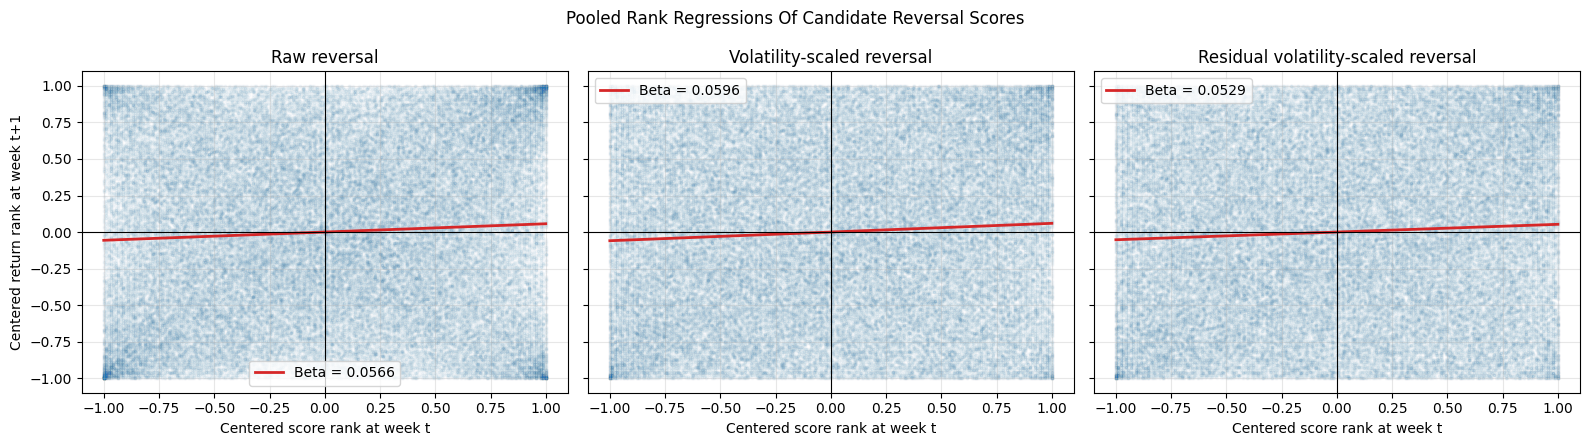

In [11]:
# Visualize the global ranked relationship for each candidate signal.
fig, axes = plt.subplots(1, len(score_diagnostics), figsize=(16, 4.5), sharex=True, sharey=True)
line_x = np.linspace(-1, 1, 101)
for ax, (name, result) in zip(axes, score_diagnostics.items()):
    pooled = result["pooled"]
    beta = result["summary"]["Pooled rank beta"]
    ax.scatter(pooled["score_rank"], pooled["forward_return_rank"], s=3, alpha=0.025, rasterized=True)
    ax.plot(line_x, beta * line_x, color="C3", linewidth=2, label=f"Beta = {beta:.4f}")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("Centered score rank at week t")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Centered return rank at week t+1")
fig.suptitle("Pooled Rank Regressions Of Candidate Reversal Scores")
fig.tight_layout()
plt.show()

### Baseline Signal Interpretation

All three reversal definitions have positive predictive content in 2010-2019. Volatility-scaled reversal has the strongest mean IC at approximately **5.96%**, compared with **5.66%** for raw reversal and **5.29%** for residual volatility-scaled reversal.

Volatility scaling is therefore retained as the economic anchor: it preserves the intuitive loser-rebound mechanism while reducing the mechanical influence of high-volatility stocks. It is not discarded after Ridge is introduced. Instead, it remains both the model's primary feature and the explicit benchmark for judging whether machine learning adds value.


## Ridge Regression Signal Model

The baseline score uses one characteristic with a fixed economic sign. Ridge regression instead estimates how several standardized characteristics jointly relate to next-week cross-sectional return ranks.

For feature vector $x_{i,t}$, the model predicts

$$
\widehat{y}_{i,t+1}
=
\widehat{\beta}_{0,t}
+x_{i,t}^{\top}\widehat{\beta}_t.
$$

The coefficients solve

$$
\widehat{\beta}
=
\arg\min_{\beta}
\sum_{(i,t)\in\mathcal{T}}
\left(
y_{i,t+1}-\beta_0-x_{i,t}^{\top}\beta
\right)^2
+\alpha\sum_j\beta_j^2.
$$

The $L_2$ penalty shrinks correlated and noisy coefficients toward zero. This is useful in equity prediction because reversal variables overlap and accounting characteristics can be unstable across time. Ridge remains interpretable: each coefficient measures the incremental association of a cross-sectionally standardized feature with the future return rank.

### Ridge Feature Set

| Feature | Definition or source | Economic intuition | Expected sign | Frequency |
| --- | --- | --- | --- | --- |
| Volatility-scaled reversal | $-R^W_{i,t}/\sigma^W_{i,t}$ | Risk-adjusted losers may rebound | Positive | Weekly |
| Raw reversal | $-R^W_{i,t}$ | Recent losers may reverse | Positive | Weekly |
| Residual reversal | $-R^{res,W}_{i,t}/\sigma^{res,W}_{i,t}$ | Idiosyncratic price pressure may unwind | Positive | Weekly |
| Recent volatility | 104-week return volatility | High risk may weaken implementation quality | Usually negative | Weekly |
| Log traded value | $\log(1+\text{63-day median traded value})$ | More liquid stocks are easier to trade | Positive | Weekly |
| Value | JKP be_me | Cheaper stocks may have higher expected returns | Positive | Monthly, carried forward |
| Quality | JKP gp_at | Profitable firms may be more resilient | Positive | Monthly, carried forward |
| Momentum | JKP ret_6_1 | Medium-term continuation complements weekly reversal | Positive | Monthly, carried forward |

Each weekly feature is winsorized at the 1st and 99th cross-sectional percentiles and standardized within that week. JKP observations are carried forward for no more than 12 monthly observations. The model therefore learns from relative characteristics that were observable at formation time.

The target is the centered next-week return rank $y_{i,t+1}$, not the raw return. The model therefore aims to rank stocks reliably rather than estimate noisy return magnitudes.


In [12]:
RIDGE_FEATURE_NAMES = (
    "vol_scaled_reversal",
    "raw_reversal",
    "residual_vol_scaled_reversal",
    "recent_weekly_volatility",
    "log_median_traded_value",
    "jkp_value",
    "jkp_quality",
    "jkp_momentum",
)


def build_weekly_ridge_features(
    market_data: pd.DataFrame,
    weekly_dates: pd.DatetimeIndex,
    candidate_scores: dict[str, pd.DataFrame],
    weekly_volatility: pd.DataFrame,
    data_dir: Path,
    liquidity_window: int,
) -> pd.DataFrame:
    """Build point-in-time weekly features and apply cross-sectional preprocessing."""
    # The rolling median dampens isolated volume spikes; missing activity is treated as no trading.
    daily_traded_value = market_data["liquidity"].unstack("id").sort_index().fillna(0.0)
    weekly_liquidity = (
        daily_traded_value.rolling(liquidity_window, min_periods=20).median()
        .reindex(weekly_dates, method="ffill")
    )

    # JKP observations are lower-frequency. Each weekly row receives only the
    # latest observation published on or before that week, with a one-year limit.
    jkp_data = pd.read_parquet(data_dir / "jkp_data.parquet").copy()
    date_level = jkp_data.index.names.index("date")
    jkp_data.index = jkp_data.index.set_levels(
        pd.to_datetime(jkp_data.index.levels[date_level]), level=date_level
    )
    jkp_data = jkp_data[~jkp_data.index.duplicated(keep="last")].sort_index()

    # Map raw JKP field names to stable model-facing labels used in calibration and backtesting.
    jkp_mapping = {
        "jkp_value": "be_me",
        "jkp_quality": "gp_at",
        "jkp_momentum": "ret_6_1",
    }
    missing_jkp = sorted(set(jkp_mapping.values()).difference(jkp_data.columns))
    if missing_jkp:
        raise ValueError(f"Missing configured JKP Ridge features: {missing_jkp}")

    # Price and liquidity features already share the weekly formation-date by security matrix shape.
    feature_frames = {
        "vol_scaled_reversal": candidate_scores["Volatility-scaled reversal"],
        "raw_reversal": candidate_scores["Raw reversal"],
        "residual_vol_scaled_reversal": candidate_scores[
            "Residual volatility-scaled reversal"
        ],
        "recent_weekly_volatility": weekly_volatility,
        "log_median_traded_value": np.log1p(weekly_liquidity),
    }
    for output_name, jkp_name in jkp_mapping.items():
        wide = jkp_data[jkp_name].unstack("id").sort_index()
        # Carry each stock-level characteristic forward for at most 12 monthly observations.
        # The 365-day tolerance also prevents stale fundamentals from entering a weekly row.
        wide = wide.ffill(limit=12)
        feature_frames[output_name] = wide.reindex(
            weekly_dates,
            method="ffill",
            tolerance=pd.Timedelta(days=365),
        )

    stacked_features = {}
    for name, frame in feature_frames.items():
        # Some source panels contain repeated security labels. Keeping the last
        # column matches the duplicate-record convention used elsewhere.
        frame = frame.loc[:, pd.Index(frame.columns).notna()]
        frame = frame.loc[:, ~frame.columns.duplicated(keep="last")]
        stacked_features[name] = frame.rename_axis(
            index="DATE", columns="ID"
        ).stack()

    # Stack wide matrices into one (DATE, ID) panel so each row is one stock-week observation.
    panel = pd.concat(stacked_features, axis=1).replace(
        [np.inf, -np.inf], np.nan
    )
    panel = panel.loc[:, list(RIDGE_FEATURE_NAMES)].sort_index()

    # Winsorize and standardize within each week so features remain comparable across stocks.
    # Transform within each week: cap extreme peers first, then express every feature in standard deviations.
    panel = CrossSectionalWinsorize(lower=0.01, upper=0.99).fit_transform(panel)
    panel = CrossSectionalZScore().fit_transform(panel)
    return panel.replace([np.inf, -np.inf], np.nan)


ridge_features = build_weekly_ridge_features(
    market_data=market_data,
    weekly_dates=weekly_dates,
    candidate_scores=candidate_scores,
    weekly_volatility=weekly_volatility,
    data_dir=DATA_DIR,
    liquidity_window=CONFIG.liquidity_window_observations,
)

# Convert returns to centered ranks so Ridge predicts relative attractiveness, not fragile magnitudes.
# This ex-post target is used for training and evaluation, never as a formation-time filter.
forward_ranks = forward_weekly_returns.rank(axis=1, method="average")
cross_section_counts = forward_weekly_returns.notna().sum(axis=1)
ridge_target_panel = (
    2 * forward_ranks.sub(1).div(cross_section_counts.sub(1), axis=0) - 1
)
ridge_target = (
    ridge_target_panel.rename_axis(index="DATE", columns="ID")
    .stack()
    .rename("next_week_rank")
)

assert ridge_features.index.names == ["DATE", "ID"]
assert ridge_target.index.names == ["DATE", "ID"]
assert tuple(ridge_features.columns) == RIDGE_FEATURE_NAMES


## Walk-Forward Training And Hyperparameter Selection

Ridge uses a rolling three-year training sample of 156 weeks and is refitted every 13 weeks. The estimated coefficients are reused for the following 13 weekly predictions, which represents a realistic quarterly model-update schedule.

At a refit date $T$:

1. identify all feature dates strictly before $T$;
2. embargo the most recent date because its next-week target is not fully known;
3. retain the preceding 156 labelled weeks;
4. estimate Ridge coefficients;
5. use those coefficients for weekly predictions until the next refit.

The regularization parameter is selected from

$$
\alpha\in
\{0.01,0.1,1,10,100,1{,}000,10{,}000\}
$$

using quarterly walk-forward predictions ending in December 2014. The criterion is the mean weekly rank IC. Once selected, $\alpha$ is held fixed for the complete 2010-2019 development prediction panel.

This is pseudo-out-of-sample model selection: no predicted week is included in its own training sample, and no 2020+ observation influences the feature set, alpha grid, training window, or refit frequency.


In [13]:
def quarterly_ridge_predictions(
    features: pd.DataFrame,
    target: pd.Series,
    prediction_dates: pd.DatetimeIndex,
    alpha: float,
    training_window_weeks: int,
    retrain_every_weeks: int,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Generate weekly predictions from Ridge models refitted once every quarter."""
    prediction_dates = pd.DatetimeIndex(prediction_dates).sort_values()
    available_dates = features.index.get_level_values("DATE").unique().sort_values()
    predictions = []
    coefficient_rows = []
    schedule_rows = []

    # One fitted model serves each 13-week block, reproducing the frozen quarterly update schedule.
    for block_start in range(0, len(prediction_dates), retrain_every_weeks):
        refit_date = prediction_dates[block_start]
        block_dates = prediction_dates[
            block_start:block_start + retrain_every_weeks
        ]

        # Candidate training weeks must precede the refit date before the label embargo is applied.
        earlier_dates = available_dates[available_dates < refit_date]
        if len(earlier_dates) <= training_window_weeks:
            continue

        # The most recent feature date is embargoed because its next-week target
        # is not fully observable strictly before the refit date.
        training_dates = earlier_dates[:-1][-training_window_weeks:]
        # Joining on (DATE, ID) keeps only stock-weeks with complete predictors and a realized target.
        train_mask = features.index.get_level_values("DATE").isin(training_dates)
        training_sample = features.loc[train_mask].join(target.rename("target")).dropna()
        if training_sample.empty:
            continue

        # Ridge shrinks correlated feature coefficients while retaining a cross-sectional intercept.
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(
            training_sample.loc[:, features.columns],
            training_sample["target"],
        )

        # Predictions use only complete contemporaneous features; no future target enters inference.
        test_mask = features.index.get_level_values("DATE").isin(block_dates)
        test_features = features.loc[test_mask].dropna()
        if test_features.empty:
            continue

        block_prediction = pd.Series(
            model.predict(test_features),
            index=test_features.index,
            name="ridge_score",
        )
        predictions.append(block_prediction)
        # Store coefficients and date ranges to make every reused quarterly model auditable.
        coefficient_rows.append(
            pd.Series(model.coef_, index=features.columns, name=refit_date)
        )
        schedule_rows.append(
            {
                "Refit date": refit_date,
                "Training start": training_dates.min(),
                "Training end": training_dates.max(),
                "Training weeks": len(training_dates),
                "Prediction start": block_dates.min(),
                "Prediction end": block_dates.max(),
                "Prediction weeks": len(block_dates),
                "Training rows": len(training_sample),
            }
        )

        assert training_dates.max() < refit_date
        assert len(training_dates) == training_window_weeks
        assert len(block_dates) <= retrain_every_weeks

    if not predictions:
        raise RuntimeError("No quarterly Ridge predictions were generated.")

    # Concatenate quarterly blocks into one unique weekly stock-score panel.
    prediction = pd.concat(predictions).sort_index()
    prediction = prediction[~prediction.index.duplicated(keep="last")]
    coefficients = pd.DataFrame(coefficient_rows)
    schedule = pd.DataFrame(schedule_rows)
    assert prediction.index.get_level_values("DATE").max() <= prediction_dates.max()
    assert (schedule["Training end"] < schedule["Refit date"]).all()
    return prediction, coefficients, schedule


def select_ridge_alpha(
    features: pd.DataFrame,
    target: pd.Series,
    validation_dates: pd.DatetimeIndex,
    alpha_grid: tuple[float, ...],
    training_window_weeks: int,
    retrain_every_weeks: int,
) -> tuple[float, pd.DataFrame]:
    """Select one Ridge penalty by mean walk-forward rank IC in the tuning period."""
    rows = []
    # Every alpha is compared on the same historical dates and walk-forward training protocol.
    for alpha in alpha_grid:
        prediction, _, _ = quarterly_ridge_predictions(
            features=features,
            target=target,
            prediction_dates=validation_dates,
            alpha=alpha,
            training_window_weeks=training_window_weeks,
            retrain_every_weeks=retrain_every_weeks,
        )
        # Align predictions with realized ranks only for validation scoring, never for model inputs.
        aligned = pd.concat(
            [prediction.rename("prediction"), target.rename("target")],
            axis=1,
        ).dropna()
        # Compute one rank IC per week so alpha selection does not overweight larger cross-sections.
        weekly_ic = aligned.groupby(level="DATE").apply(
            lambda cross_section: cross_section["prediction"].corr(
                cross_section["target"], method="spearman"
            ),
            include_groups=False,
        )
        rows.append(
            {
                "Alpha": alpha,
                "Mean validation IC": weekly_ic.mean(),
                "IC standard deviation": weekly_ic.std(),
                "Validation weeks": weekly_ic.notna().sum(),
            }
        )

    # Highest mean IC wins; the smaller alpha breaks an exact performance tie deterministically.
    comparison = pd.DataFrame(rows).sort_values(
        ["Mean validation IC", "Alpha"],
        ascending=[False, True],
    )
    selected_alpha = float(comparison.iloc[0]["Alpha"])
    return selected_alpha, comparison.reset_index(drop=True)


,Alpha,Mean validation IC,IC standard deviation,Validation weeks
0,"1,000.0000",0.1011,0.1455,261
1,100.0000,0.1001,0.1540,261
2,"10,000.0000",0.1001,0.1363,261
3,10.0000,0.0996,0.1562,261
4,1.0000,0.0994,0.1564,261
5,0.1000,0.0994,0.1564,261
6,0.0100,0.0994,0.1564,261


,Mean IC,Newey-West IC t-statistic,Pooled rank beta,Clustered beta t-statistic,Pooled rank-regression R-squared,Mean absolute-sign hit rate,Newey-West hit-rate-excess t-statistic,Average matched securities,IC weeks,Pooled observations
Volatility-scaled reversal baseline,0.0596,12.1870,0.0596,10.9667,0.0036,0.5162,4.5571,182.6775,521.0000,"95,175.0000"
Quarterly Ridge prediction,0.0874,15.8712,0.0874,14.2498,0.0076,0.5348,11.4423,122.0192,521.0000,"63,572.0000"


,Refit date,Training start,Training end,Training weeks,Prediction start,Prediction end,Prediction weeks,Training rows
0,2010-01-01,2006-12-29,2009-12-18,156,2010-01-01,2010-03-26,13,17719
1,2010-04-02,2007-03-30,2010-03-19,156,2010-04-02,2010-06-25,13,18028
2,2010-07-02,2007-06-29,2010-06-18,156,2010-07-02,2010-09-24,13,18201
3,2010-10-01,2007-09-28,2010-09-17,156,2010-10-01,2010-12-24,13,18246
4,2010-12-31,2007-12-28,2010-12-17,156,2010-12-31,2011-03-25,13,18403


,mean,std,min,max
vol_scaled_reversal,0.0397,0.0119,0.0228,0.0621
raw_reversal,0.0149,0.0047,0.0066,0.0303
residual_vol_scaled_reversal,-0.0136,0.0061,-0.0288,-0.0019
recent_weekly_volatility,-0.0299,0.0075,-0.0408,-0.0118
log_median_traded_value,0.0210,0.0097,0.0045,0.0405
jkp_value,-0.0019,0.0098,-0.0181,0.0150
jkp_quality,0.0136,0.0044,0.0049,0.0239
jkp_momentum,0.0140,0.0055,0.0039,0.0245


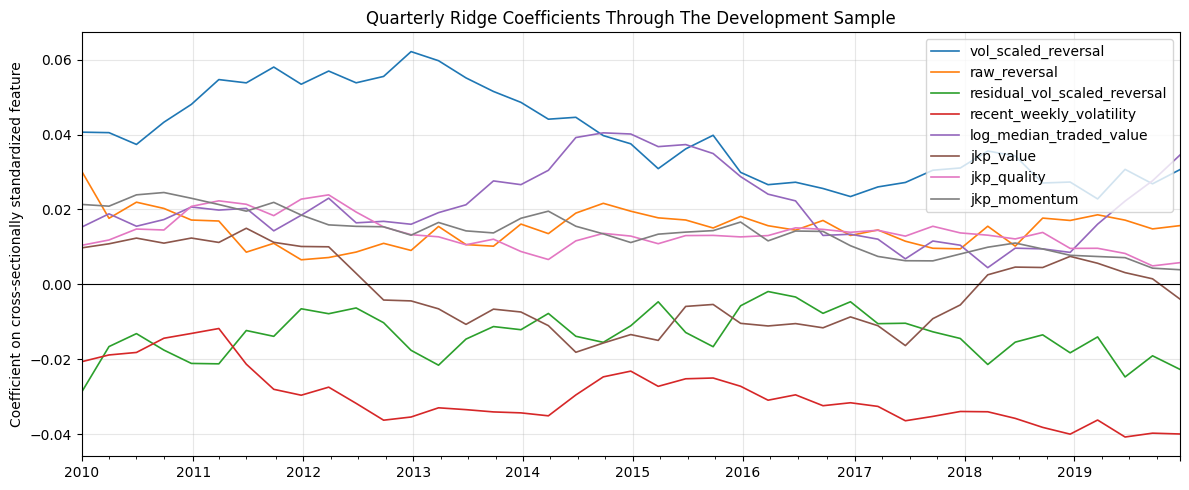

In [14]:
# Restrict hyperparameter selection to dates ending in 2014; later development data cannot choose alpha.
alpha_validation_dates = research_formation_dates[
    research_formation_dates <= pd.Timestamp(CONFIG.ridge_alpha_selection_end_date)
]
selected_ridge_alpha, ridge_alpha_comparison = select_ridge_alpha(
    features=ridge_features,
    target=ridge_target,
    validation_dates=alpha_validation_dates,
    alpha_grid=CONFIG.ridge_alpha_grid,
    training_window_weeks=CONFIG.ridge_training_window_weeks,
    retrain_every_weeks=CONFIG.ridge_retrain_every_weeks,
)

# Refit the selected specification across 2010-2019 to produce development-only walk-forward scores.
ridge_prediction_series, ridge_coefficients, ridge_refit_schedule = (
    quarterly_ridge_predictions(
        features=ridge_features,
        target=ridge_target,
        prediction_dates=research_formation_dates,
        alpha=selected_ridge_alpha,
        training_window_weeks=CONFIG.ridge_training_window_weeks,
        retrain_every_weeks=CONFIG.ridge_retrain_every_weeks,
    )
)
# Return to a week-by-security matrix for portfolio formation and align the baseline to identical weeks.
ridge_score = ridge_prediction_series.unstack("ID").reindex(research_formation_dates)
baseline_score = candidate_scores[CONFIG.selected_signal_name].reindex(
    research_formation_dates
)

# Persist reproducible development scores and coefficient histories for downstream audit work.
ridge_score.stack().rename("ridge_score").to_frame().to_parquet(
    CONFIG.development_score_path
)
ridge_coefficients.to_parquet(CONFIG.coefficient_path)

# Compare predictive ranking quality before introducing holdings, turnover, or transaction costs.
ridge_diagnostics = score_vector_diagnostics(ridge_score)
ridge_baseline_comparison = pd.DataFrame(
    {
        "Volatility-scaled reversal baseline": score_diagnostics[
            CONFIG.selected_signal_name
        ]["summary"],
        "Quarterly Ridge prediction": ridge_diagnostics["summary"],
    }
).T

display(ridge_alpha_comparison.round(4))
if selected_ridge_alpha in (min(CONFIG.ridge_alpha_grid), max(CONFIG.ridge_alpha_grid)):
    print(
        "Warning: selected Ridge alpha is on the search-grid boundary; "
        "interpret the shrinkage choice cautiously."
    )
display(ridge_baseline_comparison.round(4))
display(ridge_refit_schedule.head())
display(ridge_coefficients.describe().T[["mean", "std", "min", "max"]].round(4))

ax = ridge_coefficients.plot(figsize=(12, 5), linewidth=1.2)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("Quarterly Ridge Coefficients Through The Development Sample")
ax.set_ylabel("Coefficient on cross-sectionally standardized feature")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

assert ridge_score.notna().sum(axis=1).median() >= CONFIG.minimum_cross_section_size
assert ridge_refit_schedule["Prediction weeks"].max() <= CONFIG.ridge_retrain_every_weeks


### Ridge Development Results

The expanded search selects an interior penalty of **$\alpha=1{,}000$**, with a validation IC of approximately **10.11%**. This is preferable to selecting a boundary value because the search now shows that still stronger shrinkage at $10{,}000$ does not improve the mean validation IC.

Across the full 2010-2019 walk-forward sample:

| Diagnostic | Reversal baseline | Quarterly Ridge |
| --- | ---: | ---: |
| Mean weekly IC | 5.96% | **8.74%** |
| Newey-West IC t-statistic | 12.19 | **15.87** |
| Directional hit rate | 51.62% | **53.48%** |
| Pooled rank $R^2$ | 0.36% | **0.76%** |
| Average matched stocks | 182.7 | 122.0 |

Ridge materially improves rank prediction, although coverage is lower because every stock must have all eight features available. Coefficients are economically sensible overall: volatility-scaled reversal remains the largest positive driver, while recent volatility is persistently negative. Value contributes little on average, and coefficient variation confirms that relationships are not perfectly stable.

The model is therefore accepted as the selected score, while reversal remains the benchmark. The evidence is predictive rather than causal, and the small rank $R^2$ is normal for noisy weekly equity returns.


## Portfolio Construction And Economic Feasibility

Predictive diagnostics do not reveal whether a score can survive turnover and costs. The next sections translate the weekly Ridge ranking into two transparent development portfolios:

1. a continuous market-neutral portfolio using the full ranking;
2. an HML portfolio concentrating on the top and bottom 10%.

These are diagnostic long-short implementations. Their purpose is to identify where the payoff originates and whether the long rebound leg is strong enough to justify the final long-only strategy. Target weights are formed at week $t$ and applied only to returns from week $t+1$. Missing future returns are assigned zero rather than used to renormalize holdings after the fact.


In [15]:
# Convert the annual implementation fee to an equivalent compounded weekly deduction.
FIXED_COST_WEEKLY = (1 + CONFIG.fixed_cost_annual) ** (1 / CONFIG.weeks_per_year) - 1


def component_result(gross: pd.Series, turnover: pd.Series, fixed_cost_share: float = 1.0) -> dict:
    '''Attach variable and fixed costs to one return contribution series.'''
    net = gross - CONFIG.variable_transaction_cost * turnover - fixed_cost_share * FIXED_COST_WEEKLY
    return {"gross": gross, "turnover": turnover, "net": net}


def evaluate_target_weights(target_weights: pd.DataFrame) -> dict:
    '''Apply formation-time holdings to next-week returns without ex-post reweighting.'''
    # Preserve the submitted target weights; empty weeks are removed rather than backfilled.
    weights = target_weights.fillna(0.0)
    weights = weights.loc[weights.abs().sum(axis=1) > 0]
    # Positive and negative books are retained separately for exact return and turnover attribution.
    long_weights = weights.clip(lower=0.0)
    short_weights = weights.clip(upper=0.0)

    gross_returns = {}
    leg_returns = {}
    coverage = {}

    for date, row in weights.iterrows():
        # Security reindexing guarantees that each formation weight multiplies its own next-week return.
        next_week_return = forward_weekly_returns.loc[date].reindex(row.index)
        # Coverage records how much intended gross exposure has an observed ex-post return.
        valid_weight = row[next_week_return.notna()].abs().sum()
        coverage[date] = valid_weight / row.abs().sum()

        # Missing next-week returns are not used to rebalance ex post.
        realized = next_week_return.fillna(0.0)
        long_return = (long_weights.loc[date] * realized).sum()
        short_return = (short_weights.loc[date] * realized).sum()

        leg_returns[date] = (long_return, short_return)
        gross_returns[date] = long_return + short_return

    gross = pd.Series(gross_returns, dtype=float, name="Gross return")
    legs = pd.DataFrame.from_dict(
        leg_returns,
        orient="index",
        columns=["Long contribution", "Short contribution"],
    )

    weights = weights.reindex(gross.index)
    long_weights = long_weights.reindex(gross.index)
    short_weights = short_weights.reindex(gross.index)

    # One-way turnover is the absolute change in weights; leg totals reconcile to the combined book.
    turnover = weights.diff().abs().sum(axis=1)
    long_turnover = long_weights.diff().abs().sum(axis=1)
    short_turnover = short_weights.diff().abs().sum(axis=1)

    # The first observation represents initial capital deployment from a zero-weight portfolio.
    turnover.iloc[0] = weights.iloc[0].abs().sum()
    long_turnover.iloc[0] = long_weights.iloc[0].abs().sum()
    short_turnover.iloc[0] = short_weights.iloc[0].abs().sum()

    if not np.allclose(turnover, long_turnover + short_turnover):
        raise ValueError("Combined turnover does not equal exact leg turnover.")

    # Costs are applied only after gross returns and exact formation-time turnover are fixed.
    result = component_result(gross, turnover)
    result.update(
        {
            "legs": legs,
            "coverage": pd.Series(coverage, name="Observed weight coverage"),
            "long_turnover": long_turnover,
            "short_turnover": short_turnover,
        }
    )
    return result


def economic_summary(result: dict, label: str) -> pd.Series:
    '''Summarize implementation economics on a common cost basis.'''
    gross = result["gross"]
    net = result["net"]
    turnover = result["turnover"]

    # Exclude initial deployment when measuring recurring return earned per unit of trading.
    recurring = pd.concat(
        [gross.rename("gross_return"), turnover.rename("turnover")],
        axis=1,
    ).dropna().iloc[1:]
    # Wealth and inference use gross returns; net metrics separately include both configured costs.
    wealth = (1 + gross).cumprod()
    _, gross_t = newey_west_mean_test(gross)

    return pd.Series(
        {
            "Gross annual return": (1 + gross).prod() ** (CONFIG.weeks_per_year / len(gross)) - 1,
            "Gross annual volatility": gross.std() * np.sqrt(CONFIG.weeks_per_year),
            "Gross Sharpe": gross.mean() / gross.std() * np.sqrt(CONFIG.weeks_per_year),
            "Newey-West gross return t-statistic": gross_t,
            "Gross maximum drawdown": (wealth / wealth.cummax() - 1).min(),
            "Net annual return": (1 + net).prod() ** (CONFIG.weeks_per_year / len(net)) - 1,
            "Net Sharpe": net.mean() / net.std() * np.sqrt(CONFIG.weeks_per_year),
            "Average weekly turnover": turnover.mean(),
            "Gross bps per trade": 1e4 * recurring["gross_return"].mean() / recurring["turnover"].mean(),
            "Weeks": len(gross),
        },
        name=label,
    )


def leg_summary(result: dict) -> pd.DataFrame:
    '''Report long, short and combined gross return contributions separately.'''
    legs = result["legs"].copy()
    legs["Combined gross"] = legs.sum(axis=1)

    return pd.DataFrame(
        {
            "Annualized average contribution": legs.mean() * CONFIG.weeks_per_year,
            "Annualized volatility": legs.std() * np.sqrt(CONFIG.weeks_per_year),
            "Newey-West return t-statistic": legs.apply(lambda x: newey_west_mean_test(x)[1]),
        }
    )


### Continuous Rank-Weighted Portfolio

The continuous portfolio tests whether Ridge's ordering is useful throughout the full cross-section. The weekly Ridge scores are converted to centered ranks:

$$
z_{i,t}
=
2\frac{\operatorname{Rank}_t(\widehat{y}_{i,t+1})-1}{N_t-1}-1.
$$

Unit-gross market-neutral target weights are

$$
w^{cont}_{i,t}
=
\frac{z_{i,t}}{\sum_j\lvert z_{j,t}\rvert}.
$$

The portfolio allocates approximately $+0.50$ to high-prediction stocks and $-0.50$ to low-prediction stocks. It tests broad ranking quality rather than only extreme observations.


In [16]:
def continuous_rank_targets(score: pd.DataFrame) -> pd.DataFrame:
    """Construct zero-centered, unit-gross target weights from a score ranking."""
    targets = {}

    for date in research_formation_dates:
        # Build each cross-section only from scores observable for that formation week.
        scores = score.loc[date].dropna()
        enough_assets = len(scores) >= CONFIG.minimum_cross_section_size
        enough_signal_values = scores.nunique() >= CONFIG.minimum_distinct_cross_section_values
        if not (enough_assets and enough_signal_values):
            continue

        # Dividing centered ranks by absolute exposure creates a market-neutral unit-gross portfolio.
        signal = centered_rank(scores)
        weights = signal / signal.abs().sum()

        # Reinsert zero weights for absent names so turnover is comparable across changing universes.
        target = pd.Series(0.0, index=score.columns)
        target.loc[weights.index] = weights
        targets[date] = target

    return pd.DataFrame(targets).T


selected_score = ridge_score
continuous_targets = continuous_rank_targets(selected_score)
continuous_result = evaluate_target_weights(continuous_targets)


In [17]:
# Economic performance and the source of the long-short payoff.
continuous_metrics = economic_summary(continuous_result, "Continuous rank-weighted")
continuous_leg_metrics = leg_summary(continuous_result)
display(continuous_metrics.to_frame().T.round(4))
display(continuous_leg_metrics.round(4))

,Gross annual return,Gross annual volatility,Gross Sharpe,Newey-West gross return t-statistic,Gross maximum drawdown,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade,Weeks
Continuous rank-weighted,0.1289,0.0692,1.7895,5.8149,-0.1092,0.0069,0.1340,1.0051,23.2367,521.0000


,Annualized average contribution,Annualized volatility,Newey-West return t-statistic
Long contribution,0.1153,0.0724,5.1611
Short contribution,0.0085,0.0824,0.2944
Combined gross,0.1238,0.0692,5.8149


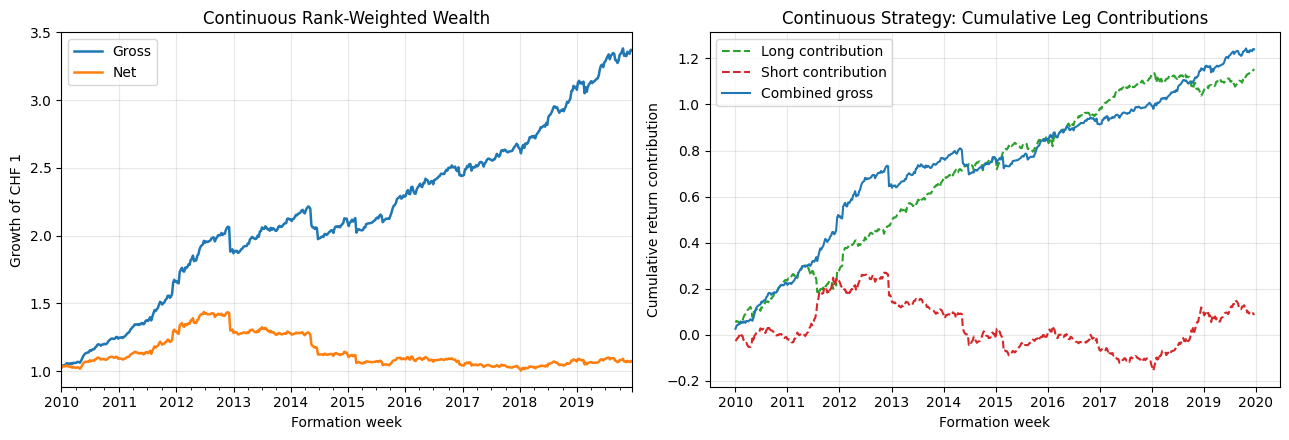

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pd.concat(
    {"Gross": continuous_result["gross"], "Net": continuous_result["net"]}, axis=1
).add(1).cumprod().plot(ax=axes[0], linewidth=1.8)
axes[0].set_title("Continuous Rank-Weighted Wealth")
axes[0].set_ylabel("Growth of CHF 1")

# Leg contributions are additive returns, so cumulative sums reveal which side drives the spread.
continuous_cumulative_legs = continuous_result["legs"].assign(
    **{"Combined gross": continuous_result["legs"].sum(axis=1)}
).cumsum()
axes[1].plot(continuous_cumulative_legs.index, continuous_cumulative_legs["Long contribution"], color="C2", linestyle="--", label="Long contribution")
axes[1].plot(continuous_cumulative_legs.index, continuous_cumulative_legs["Short contribution"], color="C3", linestyle="--", label="Short contribution")
axes[1].plot(continuous_cumulative_legs.index, continuous_cumulative_legs["Combined gross"], color="C0", linewidth=1.5, label="Combined gross")
axes[1].set_title("Continuous Strategy: Cumulative Leg Contributions")
axes[1].set_ylabel("Cumulative return contribution")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Top-Tail HML Portfolio

The HML portfolio tests whether predictive value is concentrated in the most extreme Ridge scores. Let $H_t$ and $L_t$ denote the highest and lowest 10% of the weekly ranking. Each leg is equally weighted with gross exposure 0.50:

$$
w^{HML}_{i,t}
=
\begin{cases}
\frac{0.50}{\lvert H_t\rvert}, & i\in H_t,\\
-\frac{0.50}{\lvert L_t\rvert}, & i\in L_t,\\
0, & \text{otherwise}.
\end{cases}
$$

The realized spread is

$$
R^{HML}_{t+1}
=
0.50\,\overline{R}_{H,t+1}
-0.50\,\overline{R}_{L,t+1}.
$$

This construction is more concentrated and can capture strong dislocations, but it is also more sensitive to estimation noise and constituent turnover.


In [19]:
def hml_targets(score: pd.DataFrame) -> pd.DataFrame:
    '''Construct equal-weight high-minus-low target weights from score tails.'''
    targets = {}

    for date in research_formation_dates:
        scores = score.loc[date].dropna()
        # Tail size adapts to weekly coverage while preserving the frozen 10% selection fraction.
        n_tail = int(np.floor(CONFIG.hml_tail_fraction * len(scores)))
        if len(scores) < CONFIG.minimum_cross_section_size or n_tail < 1:
            continue

        # Highest predicted rebound names form the long leg; lowest scores form the short leg.
        ordered_scores = scores.sort_values()
        high_ids = ordered_scores.tail(n_tail).index
        low_ids = ordered_scores.head(n_tail).index

        target = pd.Series(0.0, index=score.columns)
        # Equal weighting gives each leg fixed gross exposure independent of the number of eligible stocks.
        target.loc[high_ids] = CONFIG.leg_gross_exposure / n_tail
        target.loc[low_ids] = -CONFIG.leg_gross_exposure / n_tail
        targets[date] = target

    return pd.DataFrame(targets).T


hml_target_weights = hml_targets(selected_score)
hml_result = evaluate_target_weights(hml_target_weights)


In [20]:
# Report HML economics separately from its long and short return contributions.
hml_metrics = economic_summary(hml_result, "HML tails")
hml_leg_metrics = leg_summary(hml_result)
display(hml_metrics.to_frame().T.round(4))
display(hml_leg_metrics.round(4))

,Gross annual return,Gross annual volatility,Gross Sharpe,Newey-West gross return t-statistic,Gross maximum drawdown,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade,Weeks
HML tails,0.1850,0.1648,1.1174,3.6138,-0.3106,0.0206,0.2099,1.3426,26.5093,521.0000


,Annualized average contribution,Annualized volatility,Newey-West return t-statistic
Long contribution,0.1600,0.1006,5.3266
Short contribution,0.0242,0.1548,0.4688
Combined gross,0.1842,0.1648,3.6138


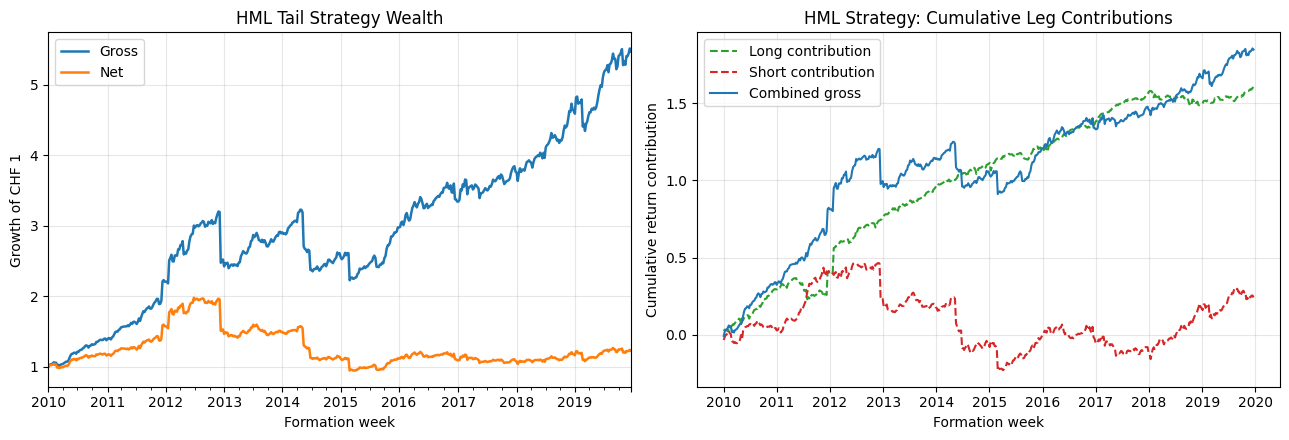

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pd.concat({"Gross": hml_result["gross"], "Net": hml_result["net"]}, axis=1).add(1).cumprod().plot(
    ax=axes[0], linewidth=1.8
)
axes[0].set_title("HML Tail Strategy Wealth")
axes[0].set_ylabel("Growth of CHF 1")

# Plot additive leg contributions beside compounded wealth to separate source from investor outcome.
hml_cumulative_legs = hml_result["legs"].assign(
    **{"Combined gross": hml_result["legs"].sum(axis=1)}
).cumsum()
axes[1].plot(hml_cumulative_legs.index, hml_cumulative_legs["Long contribution"], color="C2", linestyle="--", label="Long contribution")
axes[1].plot(hml_cumulative_legs.index, hml_cumulative_legs["Short contribution"], color="C3", linestyle="--", label="Short contribution")
axes[1].plot(hml_cumulative_legs.index, hml_cumulative_legs["Combined gross"], color="C0", linewidth=1.5, label="Combined gross")
axes[1].set_title("HML Strategy: Cumulative Leg Contributions")
axes[1].set_ylabel("Cumulative return contribution")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Tradability Filters And Baseline Comparison

The broad-universe results may rely on small or intermittently traded stocks. The selected Ridge score is therefore restricted using only formation-time information:

| Filter | Point-in-time measurement | Rule |
| --- | --- | --- |
| Ridge availability | Current weekly Ridge prediction | Non-missing score |
| Liquidity | Median daily traded value | Last 63 observations at least CHF 100,000 |
| Trading activity | Longest run of zero traded value | At most 10 days in the last 365 observations |

Missing traded-value observations are treated as zero because they represent days without recorded trading activity. Ridge and reversal are then evaluated on their **common tradable universe**, so differences reflect the score rather than different stock coverage.

Tradability reduces the average Ridge universe from roughly 125 available scores to approximately 93 common eligible stocks.


In [22]:
# Missing traded values represent days without recorded activity and are therefore set to zero.
daily_traded_value = market_data["liquidity"].unstack("id").sort_index()
weekday_mask = np.asarray(daily_traded_value.index.dayofweek < CONFIG.weekday_upper_bound).copy()
weekday_mask[-CONFIG.terminal_rows_retained:] = True
daily_traded_value = daily_traded_value.loc[weekday_mask].fillna(0.0)

trading_dates = pd.DatetimeIndex(prices.index).sort_values()
rebalance_date = {}
for signal_date in selected_score.index:
    valid_trading_dates = trading_dates[trading_dates <= signal_date]
    if len(valid_trading_dates):
        rebalance_date[signal_date] = valid_trading_dates[-1]

score_records = selected_score.rename_axis(index="signal_date", columns="id")
score_records = score_records.stack().rename("score").reset_index()
score_records["date"] = score_records["signal_date"].map(rebalance_date)
score_records = score_records.dropna(subset=["date"]).set_index(["date", "id"]).sort_index()


def longest_zero_run(values: pd.Series) -> float:
    '''Return the longest consecutive spell of zero recorded trading activity.'''
    zero = values.eq(0).astype(int)
    return zero.groupby(values.ne(0).astype(int).cumsum()).sum().max()


In [23]:
# Apply identical point-in-time tradability filters to Ridge and baseline scores.
filtered_score = pd.DataFrame(
    np.nan, index=research_formation_dates, columns=selected_score.columns
)
filtered_baseline_score = pd.DataFrame(
    np.nan, index=research_formation_dates, columns=baseline_score.columns
)
universe_rows = []

for date in research_formation_dates:
    # Map the Friday signal week to the latest actual trading date available at formation.
    trade_date = rebalance_date[date]
    score_dates = score_records.index.get_level_values("date")
    recent_score_mask = (
        (score_dates <= trade_date)
        & (score_dates >= trade_date - pd.Timedelta(days=CONFIG.score_availability_lookback_days))
    )
    # The last eligible record per stock is used only if it falls inside the one-year availability window.
    recent_scores = score_records.loc[recent_score_mask]
    score_snapshot = recent_scores.groupby("id").last()["score"].dropna()

    # Both liquidity statistics end at the trade date and therefore use no post-formation activity.
    liquidity_history = daily_traded_value.loc[:trade_date]
    median_traded_value = liquidity_history.tail(
        CONFIG.liquidity_window_observations
    ).median()
    zero_liquidity_run = liquidity_history.tail(
        CONFIG.liquidity_gap_window_observations
    ).apply(longest_zero_run)

    # A stock must satisfy both typical traded value and the maximum consecutive zero-volume gap.
    liquid_ids = median_traded_value[
        median_traded_value >= CONFIG.minimum_median_daily_traded_value
    ].index
    active_ids = zero_liquidity_run[
        zero_liquidity_run <= CONFIG.maximum_zero_liquidity_gap
    ].index
    eligible_ids = score_snapshot.index.intersection(liquid_ids).intersection(active_ids)

    # Restrict Ridge and reversal to common names so performance differences come from signals, not coverage.
    baseline_snapshot = baseline_score.loc[date].reindex(eligible_ids).dropna()
    common_ids = eligible_ids.intersection(baseline_snapshot.index)
    filtered_score.loc[date, common_ids] = score_snapshot.loc[common_ids]
    filtered_baseline_score.loc[date, common_ids] = baseline_snapshot.loc[common_ids]
    universe_rows.append(
        {
            "Available Ridge scores": len(score_snapshot),
            "Passing liquidity": len(score_snapshot.index.intersection(liquid_ids)),
            "Passing gap screen": len(score_snapshot.index.intersection(active_ids)),
            "Passing all filters": len(eligible_ids),
            "Common Ridge/baseline universe": len(common_ids),
        }
    )

# Summarize each filtering stage to expose where investable-universe coverage is lost.
eligible_universe = pd.DataFrame(universe_rows, index=research_formation_dates)
eligible_universe_summary = eligible_universe.agg(["mean", "median", "min", "max"]).T
display(eligible_universe_summary.round(1))

assert filtered_score.notna().sum(axis=1).equals(
    filtered_baseline_score.notna().sum(axis=1)
)


,mean,median,min,max
Available Ridge scores,125.4000,124.0000,119.0000,133.0000
Passing liquidity,93.9000,96.0000,79.0000,104.0000
Passing gap screen,118.4000,119.0000,110.0000,127.0000
Passing all filters,93.2000,95.0000,78.0000,103.0000
Common Ridge/baseline universe,93.2000,95.0000,78.0000,103.0000


In [24]:
# Compare Ridge before and after filtering, with reversal retained as the baseline.
filtered_signal_diagnostics = score_vector_diagnostics(filtered_score)
filtered_baseline_diagnostics = score_vector_diagnostics(filtered_baseline_score)
selected_signal_diagnostic_comparison = pd.DataFrame(
    {
        "Ridge - broad universe": ridge_diagnostics["summary"],
        "Ridge - tradability filtered": filtered_signal_diagnostics["summary"],
        "Reversal baseline - tradability filtered": filtered_baseline_diagnostics["summary"],
    }
).T
display(selected_signal_diagnostic_comparison.round(4))


,Mean IC,Newey-West IC t-statistic,Pooled rank beta,Clustered beta t-statistic,Pooled rank-regression R-squared,Mean absolute-sign hit rate,Newey-West hit-rate-excess t-statistic,Average matched securities,IC weeks,Pooled observations
Ridge - broad universe,0.0874,15.8712,0.0874,14.2498,0.0076,0.5348,11.4423,122.0192,521.0000,"63,572.0000"
Ridge - tradability filtered,0.0626,9.4172,0.0626,9.5675,0.0039,0.5281,7.1733,93.1516,521.0000,"48,532.0000"
Reversal baseline - tradability filtered,0.0418,7.0744,0.0418,6.6548,0.0017,0.5047,1.0076,93.1516,521.0000,"48,532.0000"


### Effect Of Tradability On Signal And Portfolio Economics

Filtering weakens but does not eliminate Ridge's predictive advantage:

| Score | Mean weekly IC |
| --- | ---: |
| Ridge, broad universe | 8.74% |
| Ridge, tradable universe | **6.36%** |
| Reversal baseline, tradable universe | 4.18% |

The decline from 8.74% to 6.36% shows that some predictive content is associated with excluded names. However, Ridge remains stronger than reversal on identical tradable stocks.

The unsmoothed tradable economic comparison is:

| Portfolio | Ridge gross annual return | Reversal gross annual return |
| --- | ---: | ---: |
| Continuous | **11.27%** | 8.90% |
| HML tails | **15.63%** | 15.48% |

Ridge adds clear value to the full continuous ordering but only a small improvement in the extreme tails. This is consistent with a regularized linear model improving broad ranking quality more than identifying rare extreme winners.


In [25]:
# Broad-versus-filtered economics: compare combined strategies and exact leg contributions.
filtered_continuous_result = evaluate_target_weights(continuous_rank_targets(filtered_score))
filtered_hml_result = evaluate_target_weights(hml_targets(filtered_score))

# Report combined and exact leg-attribution economics on one common basis.
strategy_results = {
    "Continuous rank-weighted": {
        "Broad universe": continuous_result,
        "Tradability filtered": filtered_continuous_result,
    },
    "HML tails": {
        "Broad universe": hml_result,
        "Tradability filtered": filtered_hml_result,
    },
}
economic_comparisons = {}
for strategy, universes in strategy_results.items():
    rows = []
    # Apply identical metrics and cost assumptions to broad and filtered implementations.
    for universe, result in universes.items():
        rows.append(economic_summary(result, f"{universe} - Combined"))
        # Charge each leg its own turnover and half the fixed fee to preserve additive attribution.
        for leg, turnover_key in [("Long contribution", "long_turnover"), ("Short contribution", "short_turnover")]:
            gross = result["legs"][leg].rename("Gross return")
            turnover = result[turnover_key]
            leg_result = {
                "gross": gross,
                "turnover": turnover,
                "net": gross - CONFIG.variable_transaction_cost * turnover - CONFIG.fixed_cost_leg_share * FIXED_COST_WEEKLY,
            }
            rows.append(economic_summary(leg_result, f"{universe} - {leg}"))
    economic_comparisons[strategy] = pd.DataFrame(rows)

display(economic_comparisons["Continuous rank-weighted"].round(4))
display(economic_comparisons["HML tails"].round(4))

# Direct economic comparison against the reversal-only baseline on identical stocks.
# Rebuild reversal portfolios on the exact Ridge-eligible universe for a controlled economic comparison.
baseline_filtered_continuous_result = evaluate_target_weights(
    continuous_rank_targets(filtered_baseline_score)
)
baseline_filtered_hml_result = evaluate_target_weights(
    hml_targets(filtered_baseline_score)
)
ridge_baseline_economic_comparison = pd.DataFrame(
    [
        economic_summary(filtered_continuous_result, "Ridge continuous"),
        economic_summary(baseline_filtered_continuous_result, "Reversal continuous"),
        economic_summary(filtered_hml_result, "Ridge HML"),
        economic_summary(baseline_filtered_hml_result, "Reversal HML"),
    ]
)
display(ridge_baseline_economic_comparison.round(4))


,Gross annual return,Gross annual volatility,Gross Sharpe,Newey-West gross return t-statistic,Gross maximum drawdown,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade,Weeks
Broad universe - Combined,0.1289,0.0692,1.7895,5.8149,-0.1092,0.0069,0.1340,1.0051,23.2367,521.0000
Broad universe - Long contribution,0.1191,0.0724,1.5917,5.1611,-0.1184,0.0533,0.7540,0.5357,39.5416,521.0000
Broad universe - Short contribution,0.0051,0.0824,0.1031,0.2944,-0.3587,-0.0476,-0.5496,0.4694,4.6266,521.0000
Tradability filtered - Combined,0.1103,0.0591,1.8023,5.5777,-0.0652,-0.0143,-0.2151,1.0503,18.7231,521.0000
Tradability filtered - Long contribution,0.1141,0.0797,1.3961,4.5254,-0.1209,0.0478,0.6256,0.5431,36.8674,521.0000
Tradability filtered - Short contribution,-0.0084,0.0857,-0.0562,-0.1688,-0.3636,-0.0641,-0.7295,0.5072,-0.7076,521.0000


,Gross annual return,Gross annual volatility,Gross Sharpe,Newey-West gross return t-statistic,Gross maximum drawdown,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade,Weeks
Broad universe - Combined,0.1850,0.1648,1.1174,3.6138,-0.3106,0.0206,0.2099,1.3426,26.5093,521.0000
Broad universe - Long contribution,0.1676,0.1006,1.5902,5.3266,-0.1309,0.0698,0.7183,0.7949,38.1260,521.0000
Broad universe - Short contribution,0.0114,0.1548,0.1563,0.4688,-0.5374,-0.0494,-0.2438,0.5477,9.6403,521.0000
Tradability filtered - Combined,0.1403,0.1370,1.0279,3.3378,-0.1979,-0.0284,-0.1415,1.4449,18.9325,521.0000
Tradability filtered - Long contribution,0.1363,0.1095,1.2191,3.9667,-0.1342,0.0411,0.4186,0.7943,31.9386,521.0000
Tradability filtered - Short contribution,-0.0013,0.1296,0.0562,0.1732,-0.4647,-0.0714,-0.5032,0.6505,3.0466,521.0000


,Gross annual return,Gross annual volatility,Gross Sharpe,Newey-West gross return t-statistic,Gross maximum drawdown,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade,Weeks
Ridge continuous,0.1103,0.0591,1.8023,5.5777,-0.0652,-0.0143,-0.2151,1.0503,18.7231,521.0000
Reversal continuous,0.0890,0.0542,1.6018,5.2639,-0.0636,-0.0637,-1.1843,1.3572,11.4993,521.0000
Ridge HML,0.1403,0.1370,1.0279,3.3378,-0.1979,-0.0284,-0.1415,1.4449,18.9325,521.0000
Reversal HML,0.1548,0.1056,1.4140,4.2457,-0.0801,-0.0507,-0.4435,1.7904,16.1121,521.0000


In [26]:
# Decomposition identifies whether screening predominantly changes either strategy leg.
filtered_leg_comparison = pd.concat(
    {
        "Continuous - broad": leg_summary(continuous_result),
        "Continuous - filtered": leg_summary(filtered_continuous_result),
        "HML - broad": leg_summary(hml_result),
        "HML - filtered": leg_summary(filtered_hml_result),
    }
)
display(filtered_leg_comparison.round(4))

Annualized average contribution  \
Continuous - broad    Long contribution                            0.1153   
                      Short contribution                           0.0085   
                      Combined gross                               0.1238   
Continuous - filtered Long contribution                            0.1113   
                      Short contribution                          -0.0048   
                      Combined gross                               0.1065   
HML - broad           Long contribution                            0.1600   
                      Short contribution                           0.0242   
                      Combined gross                               0.1842   
HML - filtered        Long contribution                            0.1335   
                      Short contribution                           0.0073   
                      Combined gross                               0.1408   

                                          Annualized volatility  \
Continuous - broad    Long contribution                  0.0724   
                      Short contribution                 0.0824   
                      Combined gross                     0.0692   
Continuous - filtered Long contribution                  0.0797   
                      Short contribution                 0.0857   
                      Combined gross                     0.0591   
HML - broad           Long contribution                  0.1006   
                      Short contribution                 0.1548   
                      Combined gross                     0.1648   
HML - filtered        Long contribution                  0.1095   
                      Short contribution                 0.1296   
                      Combined gross                     0.1370   

                                          Newey-West return t-statistic  
Continuous - broad    Long contribution                          5.1611  
                      Short contribution                         0.2944  
                      Combined gross                             5.8149  
Continuous - filtered Long contribution                          4.5254  
                      Short contribution                        -0.1688  
                      Combined gross                             5.5777  
HML - broad           Long contribution                          5.3266  
                      Short contribution                         0.4688  
                      Combined gross                             3.6138  
HML - filtered        Long contribution                          3.9667  
                      Short contribution                         0.1732  
                      Combined gross                             3.3378

## Transaction Costs And Long-Short Attribution

The combined portfolio is decomposed into its signed long and short contributions. The long leg has $+0.50$ exposure. The short contribution already includes the $-0.50$ position sign, so a negative reported short contribution means that shorting low-score stocks detracts from performance.

For target weights $w_t$, weekly turnover is measured as

$$
TO_t=\sum_i\lvert w_{i,t}-w_{i,t-1}\rvert.
$$

Net weekly return is

$$
R^{net}_t
=
R^{gross}_t
-c_v TO_t
-c_f,
$$

where $c_v=0.002$ is the variable cost per unit traded and

$$
c_f=(1+0.01)^{1/52}-1
$$

is the weekly equivalent of the 1% annual fixed implementation cost.

Gross basis points per trade are

$$
GrossBpsPerTrade
=
10^4
\frac{\mathbb{E}[R^{gross}_t]}{\mathbb{E}[TO_t]},
$$

excluding the initial portfolio establishment. This statistic measures how much gross payoff is available to absorb trading costs.


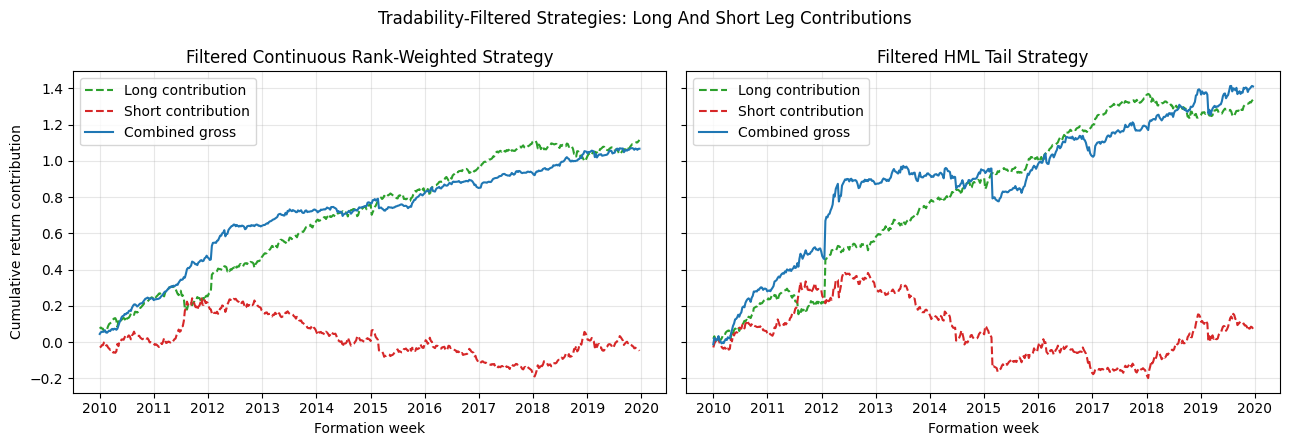

In [27]:
# Visualize the two filtered strategies using the same leg convention as their metrics.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, result, title in [
    (axes[0], filtered_continuous_result, "Filtered Continuous Rank-Weighted Strategy"),
    (axes[1], filtered_hml_result, "Filtered HML Tail Strategy"),
]:
    cumulative = result["legs"].assign(
        **{"Combined gross": result["legs"].sum(axis=1)}
    ).cumsum()
    ax.plot(cumulative.index, cumulative["Long contribution"], color="C2", linestyle="--", label="Long contribution")
    ax.plot(cumulative.index, cumulative["Short contribution"], color="C3", linestyle="--", label="Short contribution")
    ax.plot(cumulative.index, cumulative["Combined gross"], color="C0", linewidth=1.5, label="Combined gross")
    ax.set_title(title)
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Cumulative return contribution")
fig.suptitle("Tradability-Filtered Strategies: Long And Short Leg Contributions")
fig.tight_layout()
plt.show()

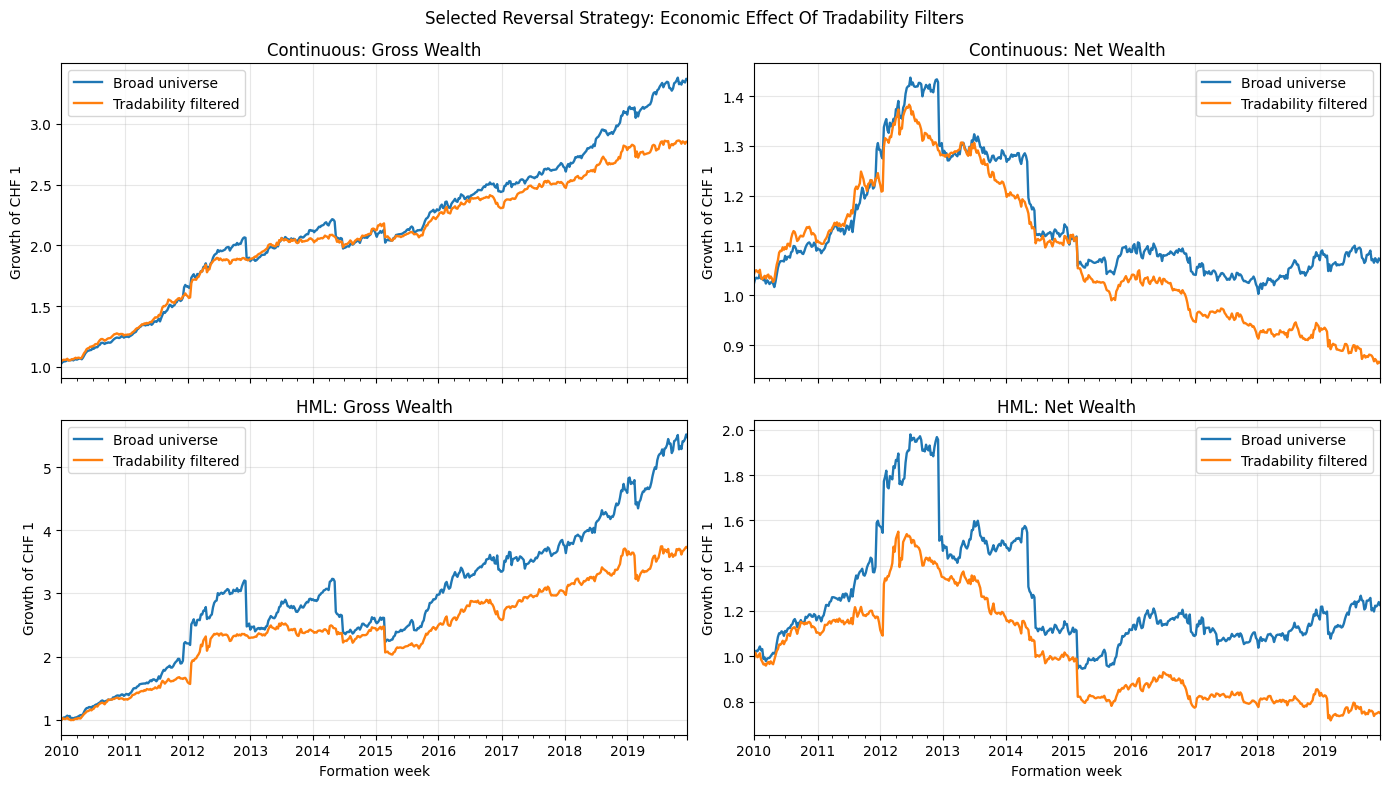

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
# Pair each broad strategy with its filtered counterpart under the same gross or net convention.
comparisons = [
    (axes[0, 0], continuous_result["gross"], filtered_continuous_result["gross"], "Continuous: Gross Wealth"),
    (axes[0, 1], continuous_result["net"], filtered_continuous_result["net"], "Continuous: Net Wealth"),
    (axes[1, 0], hml_result["gross"], filtered_hml_result["gross"], "HML: Gross Wealth"),
    (axes[1, 1], hml_result["net"], filtered_hml_result["net"], "HML: Net Wealth"),
]
for ax, broad, filtered, title in comparisons:
    pd.concat({"Broad universe": broad, "Tradability filtered": filtered}, axis=1).add(1).cumprod().plot(
        ax=ax, linewidth=1.7
    )
    ax.set_title(title)
    ax.set_ylabel("Growth of CHF 1")
    ax.grid(True, alpha=0.3)
axes[1, 0].set_xlabel("Formation week")
axes[1, 1].set_xlabel("Formation week")
fig.suptitle("Selected Reversal Strategy: Economic Effect Of Tradability Filters")
fig.tight_layout()
plt.show()

### Net Attribution On The Tradable Universe

The next tables apply the exact turnover cost of each contribution leg and allocate half of the fixed weekly cost to each leg. Long and short contributions remain components of the original unit-gross market-neutral portfolio; they are not yet standalone fully invested strategies.

The development evidence shows that the economically reliable component is generally the **long high-score basket**. The short leg is weak or unstable after costs. This result motivates the companion notebook's long-only implementation: the final strategy invests in predicted rebound candidates without requiring the low-score stocks to underperform.


In [29]:
# Compute net contribution series from the already-implemented filtered books.
tradable_strategy_results = {
    "Continuous rank-weighted": filtered_continuous_result,
    "HML tails": filtered_hml_result,
}
tradable_net_returns = {}
for strategy, result in tradable_strategy_results.items():
    tradable_net_returns[strategy] = pd.DataFrame(
        {
            "Combined net": result["net"],
            "Long net contribution": result["legs"]["Long contribution"]
            - CONFIG.variable_transaction_cost * result["long_turnover"]
            - CONFIG.fixed_cost_leg_share * FIXED_COST_WEEKLY,
            "Short net contribution": result["legs"]["Short contribution"]
            - CONFIG.variable_transaction_cost * result["short_turnover"]
            - CONFIG.fixed_cost_leg_share * FIXED_COST_WEEKLY,
        }
    )

In [30]:
# Report full economic metrics for the filtered combined portfolio and each leg.
tradable_net_metrics = {}
for strategy, result in tradable_strategy_results.items():
    rows = [economic_summary(result, "Combined strategy")]
    for leg, turnover_key, net_column in [
        ("Long contribution", "long_turnover", "Long net contribution"),
        ("Short contribution", "short_turnover", "Short net contribution"),
    ]:
        rows.append(
            economic_summary(
                {
                    "gross": result["legs"][leg],
                    "net": tradable_net_returns[strategy][net_column],
                    "turnover": result[turnover_key],
                },
                leg,
            )
        )
    tradable_net_metrics[strategy] = pd.DataFrame(rows)

display(pd.concat(tradable_net_metrics, names=["Strategy", "Component"]).round(4))

Gross annual return  \
Strategy                 Component                                 
Continuous rank-weighted Combined strategy                0.1103   
                         Long contribution                0.1141   
                         Short contribution              -0.0084   
HML tails                Combined strategy                0.1403   
                         Long contribution                0.1363   
                         Short contribution              -0.0013   

                                             Gross annual volatility  \
Strategy                 Component                                     
Continuous rank-weighted Combined strategy                    0.0591   
                         Long contribution                    0.0797   
                         Short contribution                   0.0857   
HML tails                Combined strategy                    0.1370   
                         Long contribution                    0.1095   
                         Short contribution                   0.1296   

                                             Gross Sharpe  \
Strategy                 Component                          
Continuous rank-weighted Combined strategy         1.8023   
                         Long contribution         1.3961   
                         Short contribution       -0.0562   
HML tails                Combined strategy         1.0279   
                         Long contribution         1.2191   
                         Short contribution        0.0562   

                                             Newey-West gross return t-statistic  \
Strategy                 Component                                                 
Continuous rank-weighted Combined strategy                                5.5777   
                         Long contribution                                4.5254   
                         Short contribution                              -0.1688   
HML tails                Combined strategy                                3.3378   
                         Long contribution                                3.9667   
                         Short contribution                               0.1732   

                                             Gross maximum drawdown  \
Strategy                 Component                                    
Continuous rank-weighted Combined strategy                  -0.0652   
                         Long contribution                  -0.1209   
                         Short contribution                 -0.3636   
HML tails                Combined strategy                  -0.1979   
                         Long contribution                  -0.1342   
                         Short contribution                 -0.4647   

                                             Net annual return  Net Sharpe  \
Strategy                 Component                                           
Continuous rank-weighted Combined strategy             -0.0143     -0.2151   
                         Long contribution              0.0478      0.6256   
                         Short contribution            -0.0641     -0.7295   
HML tails                Combined strategy             -0.0284     -0.1415   
                         Long contribution              0.0411      0.4186   
                         Short contribution            -0.0714     -0.5032   

                                             Average weekly turnover  \
Strategy                 Component                                     
Continuous rank-weighted Combined strategy                    1.0503   
                         Long contribution                    0.5431   
                         Short contribution                   0.5072   
HML tails                Combined strategy                    1.4449   
                         Long contribution                    0.7943   
                         Short contribution                   0

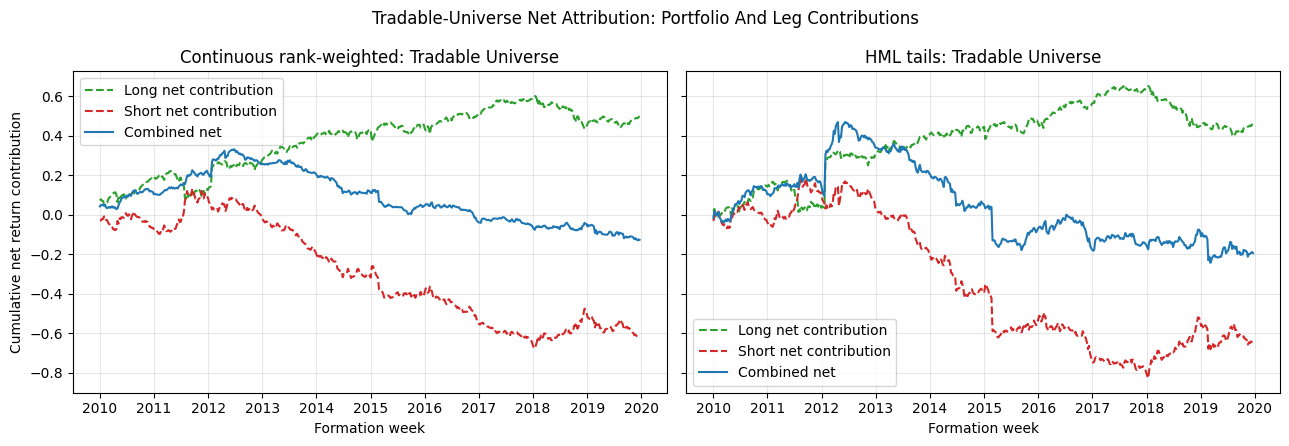

In [31]:
# Add net contribution series so long plus short equals the combined implementation.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (strategy, net_returns) in zip(axes, tradable_net_returns.items()):
    cumulative_net = net_returns.cumsum()
    ax.plot(cumulative_net.index, cumulative_net["Long net contribution"], color="C2", linestyle="--", label="Long net contribution")
    ax.plot(cumulative_net.index, cumulative_net["Short net contribution"], color="C3", linestyle="--", label="Short net contribution")
    ax.plot(cumulative_net.index, cumulative_net["Combined net"], color="C0", linewidth=1.5, label="Combined net")
    ax.set_title(f"{strategy}: Tradable Universe")
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Cumulative net return contribution")
fig.suptitle("Tradable-Universe Net Attribution: Portfolio And Leg Contributions")
fig.tight_layout()
plt.show()

#### Interpretation

Positive gross return alone is insufficient when weekly rebalancing is expensive. The relevant decision is whether the long contribution retains a positive net return and acceptable Sharpe ratio after its own turnover cost.

The attribution indicates that Ridge's long basket contains the robust payoff, whereas the signed short contribution does not consistently support the combined strategy. Consequently, the remaining development work calibrates turnover control for the investable long component rather than treating the market-neutral spread as the final product.


## EWMA Turnover Control

Ridge generates a new target portfolio each week, but immediate replacement of all positions creates substantial turnover. EWMA smoothing controls the speed at which implemented holdings approach the latest target:

$$
\widetilde{w}_t(\lambda)
=
(1-\lambda)\widetilde{w}_{t-1}
+\lambda w_t,
\qquad
\lambda\in\{0.05,0.10,\ldots,1.00\}.
$$

Interpretation:

- $\lambda=1$: implement the new target immediately;
- smaller $\lambda$: trade more slowly, reducing turnover but diluting a short-lived signal.

When a stock leaves the tradable universe, its smoothed position is set to zero before the remaining book is renormalized. The signal definition and eligible universe remain unchanged across the lambda grid.

Because the companion backtest is long-only, separate continuous and top-tail lambdas are selected by the development-sample net Sharpe of each **long contribution**, with turnover used as a secondary tie-breaker.


In [32]:
def ewma_smoothed_targets(target_weights: pd.DataFrame, lambda_value: float) -> pd.DataFrame:
    '''Smooth desired holdings recursively while resetting ineligible positions.'''
    targets = target_weights.sort_index().fillna(0.0)
    eligible = filtered_score.reindex(index=targets.index, columns=targets.columns).notna()
    state = pd.Series(0.0, index=targets.columns)
    smoothed = {}

    for date, target in targets.iterrows():
        state = (1 - lambda_value) * state + lambda_value * target
        state = state.where(eligible.loc[date], 0.0)

        long_book = state.clip(lower=0.0)
        short_book = state.clip(upper=0.0)
        if long_book.sum() == 0 or short_book.abs().sum() == 0:
            state[:] = 0.0
            continue

        # Renormalize after eligibility exits so gross exposure stays comparable.
        state = (
            CONFIG.leg_gross_exposure * long_book / long_book.sum()
            + CONFIG.leg_gross_exposure * short_book / short_book.abs().sum()
        )
        smoothed[date] = state.copy()

    return pd.DataFrame(smoothed).T


In [33]:
# Form filtered desired holdings once, then evaluate each EWMA adjustment speed.
filtered_continuous_targets = continuous_rank_targets(filtered_score)
filtered_hml_targets = hml_targets(filtered_score)
filtered_target_weights = {
    "Continuous rank-weighted": filtered_continuous_targets,
    "HML tails": filtered_hml_targets,
}
filtered_unsmoothed_results = {
    "Continuous rank-weighted": filtered_continuous_result,
    "HML tails": filtered_hml_result,
}

# Include both slow adjustment and lambda=1, which serves as the unsmoothed implementation check.
ewma_lambdas = np.round(
    np.arange(
        CONFIG.ewma_lambda_start,
        CONFIG.ewma_lambda_stop + CONFIG.ewma_lambda_step / 2,
        CONFIG.ewma_lambda_step,
    ),
    2,
)

def contribution_results(result: dict) -> dict:
    '''Return combined, long and short results on the same net-cost basis.'''
    return {
        "Combined strategy": result,
        # Each contribution uses its own turnover and half of the portfolio-level fixed fee.
        "Long contribution": component_result(
            result["legs"]["Long contribution"],
            result["long_turnover"],
            fixed_cost_share=CONFIG.fixed_cost_leg_share,
        ),
        "Short contribution": component_result(
            result["legs"]["Short contribution"],
            result["short_turnover"],
            fixed_cost_share=CONFIG.fixed_cost_leg_share,
        ),
    }


ewma_results = {}
ewma_sensitivity = {}
total_evaluations = len(filtered_target_weights) * len(ewma_lambdas)

with tqdm(total=total_evaluations, desc="EWMA sensitivity", unit="portfolio") as progress:
    for strategy, targets in filtered_target_weights.items():
        strategy_results = {}
        summary_rows = []

        # Recompute realized returns after smoothing because holdings and transaction costs both change.
        for lambda_value in ewma_lambdas:
            progress.set_postfix_str(f"{strategy}, lambda={lambda_value:.2f}")
            result = evaluate_target_weights(ewma_smoothed_targets(targets, lambda_value))
            strategy_results[lambda_value] = result

            for component, component_data in contribution_results(result).items():
                summary = economic_summary(component_data, component)
                summary["Lambda"] = lambda_value
                summary["Component"] = component
                summary_rows.append(summary)

            progress.update(1)

        # Retain full return paths for selection and a compact table for sensitivity reporting.
        ewma_results[strategy] = strategy_results
        ewma_sensitivity[strategy] = pd.DataFrame(summary_rows)

# Lambda = 1.00 must recover each unsmoothed tradable-universe implementation.
benchmark_lambda = float(np.round(CONFIG.ewma_lambda_stop, 2))
# Validate the EWMA implementation numerically before using its sensitivity results.
for strategy, benchmark in filtered_unsmoothed_results.items():
    smoothed_benchmark = ewma_results[strategy][benchmark_lambda]
    same_index = smoothed_benchmark["gross"].index.equals(benchmark["gross"].index)
    same_turnover_index = smoothed_benchmark["turnover"].index.equals(benchmark["turnover"].index)
    same_gross = np.allclose(smoothed_benchmark["gross"], benchmark["gross"])
    same_turnover = np.allclose(smoothed_benchmark["turnover"], benchmark["turnover"])
    if not (same_index and same_turnover_index and same_gross and same_turnover):
        raise ValueError(f"Lambda = 1.00 does not recover the {strategy} benchmark.")


EWMA sensitivity:   0%|          | 0/40 [00:00<?, ?portfolio/s]

In [34]:
# Report one ranked sensitivity table for each strategy component.
ewma_table_columns = [
    "Lambda",
    "Gross annual return",
    "Gross Sharpe",
    "Net annual return",
    "Net Sharpe",
    "Average weekly turnover",
    "Gross bps per trade",
]

for strategy, table in ewma_sensitivity.items():
    print(f"\n{strategy}")

    for component in ["Combined strategy", "Long contribution", "Short contribution"]:
        ranked = (
            table.loc[table["Component"] == component, ewma_table_columns]
            .sort_values("Net Sharpe", ascending=False)
            .reset_index(drop=True)
        )

        print(f"\n{component}")
        display(ranked.round(4))


Continuous rank-weighted

Combined strategy


,Lambda,Gross annual return,Gross Sharpe,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade
0,0.3000,0.0874,1.3359,0.0446,0.7121,0.2906,54.2746
1,0.3500,0.0931,1.4307,0.0441,0.7117,0.3450,48.5750
2,0.2500,0.0810,1.2339,0.0441,0.6993,0.2385,61.4928
3,0.4000,0.0979,1.5143,0.0426,0.6945,0.4017,43.7905
4,0.2000,0.0746,1.1357,0.0434,0.6842,0.1885,71.8915
5,0.1000,0.0639,0.9785,0.0431,0.6786,0.0940,124.6811
6,0.1500,0.0689,1.0505,0.0430,0.6768,0.1404,89.4051
7,0.0500,0.0589,0.8996,0.0431,0.6727,0.0492,223.6866
8,0.4500,0.1019,1.5860,0.0401,0.6610,0.4604,39.7018
9,0.5000,0.1051,1.6462,0.0365,0.6115,0.5206,36.1457



Long contribution


,Lambda,Gross annual return,Gross Sharpe,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade
0,0.3500,0.0955,1.2934,0.0696,0.9631,0.1833,91.3179
1,0.4000,0.0993,1.3300,0.0699,0.9597,0.2135,81.5217
2,0.3000,0.0913,1.2502,0.0687,0.9591,0.1543,103.7323
3,0.2000,0.0842,1.1731,0.0677,0.9582,0.0997,148.0845
4,0.2500,0.0876,1.2102,0.0681,0.9577,0.1265,121.3956
5,0.1500,0.0800,1.1263,0.0665,0.9484,0.0737,190.8137
6,0.4500,0.1025,1.3585,0.0695,0.9477,0.2444,73.4791
7,0.5000,0.1050,1.3795,0.0685,0.9279,0.2759,66.7047
8,0.1000,0.0748,1.0655,0.0641,0.9237,0.0485,272.3678
9,0.5500,0.1070,1.3934,0.0669,0.9014,0.3074,60.9932



Short contribution


...

,Lambda,Gross annual return,Gross Sharpe,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade
0,0.0500,0.0639,0.7736,0.0457,0.5699,0.0701,188.4799
1,0.1000,0.0666,0.7884,0.0411,0.5086,0.1373,98.8460
2,0.1500,0.0717,0.8256,0.0385,0.4702,0.2076,69.7108
3,0.2000,0.0786,0.8856,0.0373,0.4519,0.2803,56.0515
4,0.2500,0.0854,0.9454,0.0358,0.4320,0.3545,47.7311
5,0.3000,0.0916,0.9979,0.0337,0.4057,0.4292,41.9849
6,0.3500,0.0971,1.0411,0.0308,0.3724,0.5043,37.6870
7,0.4000,0.1021,1.0737,0.0274,0.3331,0.5794,34.3273
8,0.4500,0.1065,1.0967,0.0235,0.2895,0.6544,31.6194
9,0.5000,0.1105,1.1105,0.0193,0.2431,0.7290,29.3806



Long contribution


,Lambda,Gross annual return,Gross Sharpe,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade
0,0.1000,0.0685,1.0282,0.0550,0.8372,0.0747,174.2479
1,0.1500,0.0736,1.0796,0.0557,0.8321,0.1139,121.9584
2,0.2000,0.0786,1.1250,0.0562,0.8231,0.1539,96.0488
3,0.2500,0.0831,1.1619,0.0562,0.8066,0.1946,80.1375
4,0.0500,0.0611,0.9346,0.0518,0.8010,0.0369,319.9293
5,0.3000,0.0871,1.1910,0.0556,0.7841,0.2353,69.2806
6,0.3500,0.0907,1.2146,0.0546,0.7576,0.2764,61.3574
7,0.4000,0.0942,1.2333,0.0534,0.7289,0.3174,55.3982
8,0.4500,0.0977,1.2492,0.0523,0.7005,0.3584,50.8335
9,0.5000,0.1012,1.2606,0.0512,0.6715,0.3994,47.2254



Short contribution


,Lambda,Gross annual return,Gross Sharpe,Net annual return,Net Sharpe,Average weekly turnover,Gross bps per trade
0,0.0500,-0.0025,0.0352,-0.0109,-0.0383,0.0332,41.9846
1,0.1000,-0.0066,-0.0020,-0.0180,-0.1033,0.0626,8.6610
2,0.1500,-0.0065,-0.0002,-0.0210,-0.1297,0.0938,6.1639
3,0.2000,-0.0048,0.0153,-0.0227,-0.1436,0.1264,7.2843
4,0.2500,-0.0027,0.0335,-0.0241,-0.1559,0.1599,8.2564
5,0.3000,-0.0007,0.0513,-0.0255,-0.1690,0.1939,8.8268
6,0.3500,0.0010,0.0664,-0.0273,-0.1847,0.2279,8.9675
7,0.4000,0.0023,0.0779,-0.0295,-0.2033,0.2620,8.7867
8,0.4500,0.0031,0.0850,-0.0321,-0.2255,0.2959,8.3333
9,0.5000,0.0035,0.0884,-0.0352,-0.2502,0.3297,7.7509


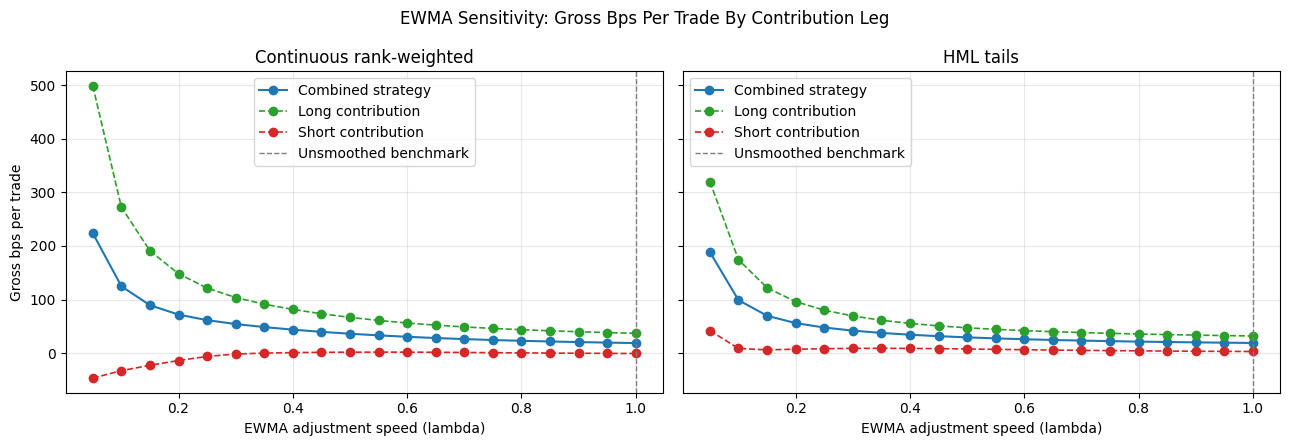

In [35]:
# Gross bps per trade separates portfolio capacity from each leg's contribution.
component_styles = {
    "Combined strategy": {"color": "C0", "linestyle": "-", "linewidth": 1.5},
    "Long contribution": {"color": "C2", "linestyle": "--", "linewidth": 1.2},
    "Short contribution": {"color": "C3", "linestyle": "--", "linewidth": 1.2},
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, strategy in zip(axes, ["Continuous rank-weighted", "HML tails"]):
    table = ewma_sensitivity[strategy]
    for component, style in component_styles.items():
        series = table[table["Component"] == component].sort_values("Lambda")
        ax.plot(series["Lambda"], series["Gross bps per trade"], marker="o", label=component, **style)
    ax.axvline(CONFIG.ewma_lambda_stop, color="C7", linestyle="--", linewidth=1.0, label="Unsmoothed benchmark")
    ax.set_title(strategy)
    ax.set_xlabel("EWMA adjustment speed (lambda)")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Gross bps per trade")
fig.suptitle("EWMA Sensitivity: Gross Bps Per Trade By Contribution Leg")
fig.tight_layout()
plt.show()

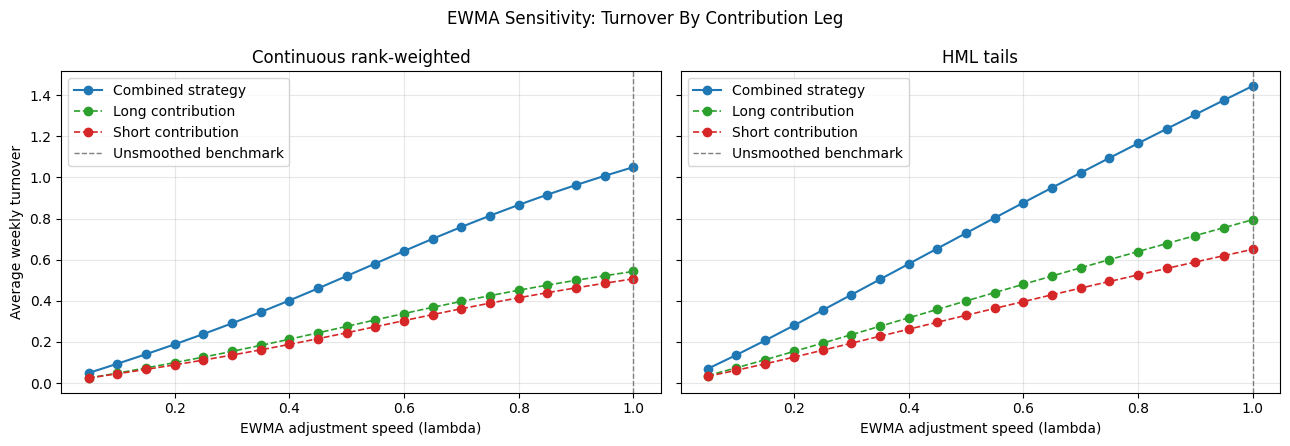

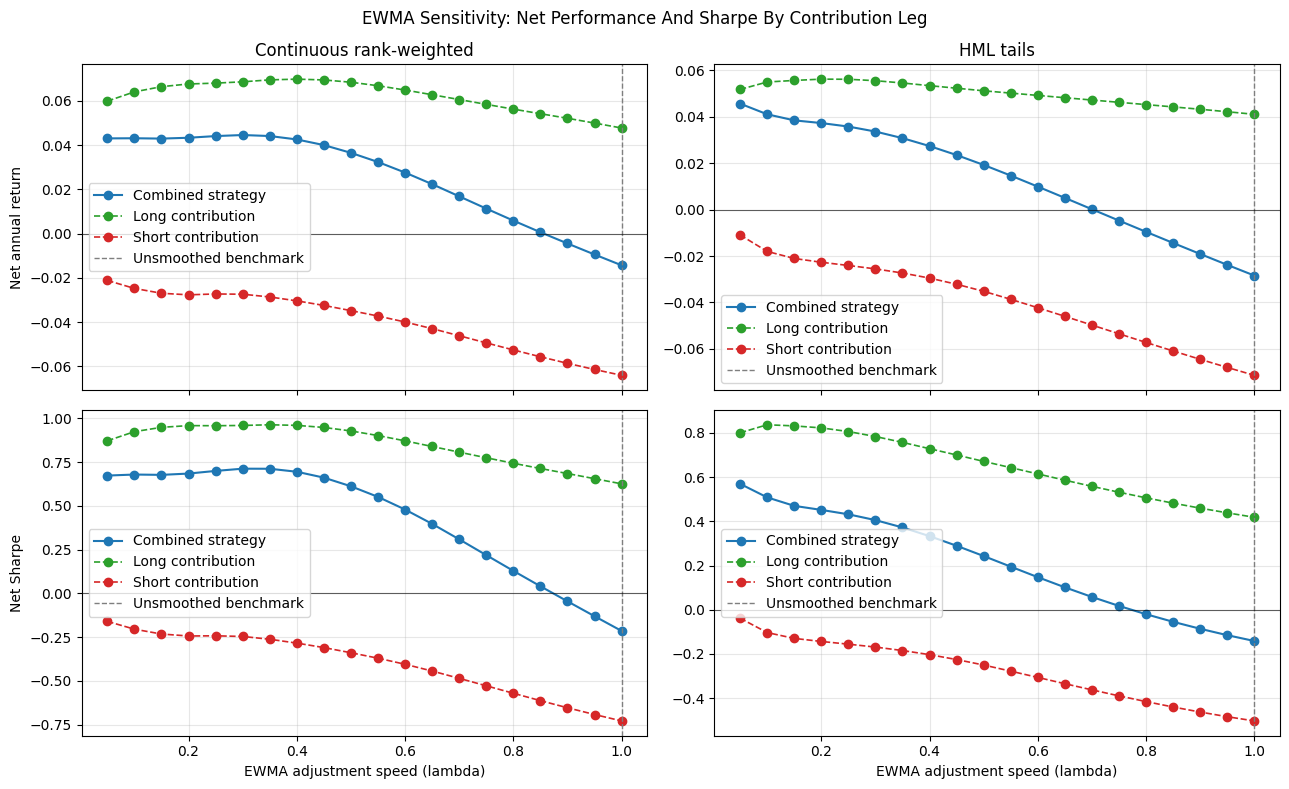

In [36]:
# Turnover identifies whether smoothing reduces trading in both contribution books.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, strategy in zip(axes, ["Continuous rank-weighted", "HML tails"]):
    # Sort each component by lambda so plotted lines represent progressively faster trading.
    table = ewma_sensitivity[strategy]
    for component, style in component_styles.items():
        series = table[table["Component"] == component].sort_values("Lambda")
        ax.plot(series["Lambda"], series["Average weekly turnover"], marker="o", label=component, **style)
    ax.axvline(CONFIG.ewma_lambda_stop, color="C7", linestyle="--", linewidth=1.0, label="Unsmoothed benchmark")
    ax.set_title(strategy)
    ax.set_xlabel("EWMA adjustment speed (lambda)")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Average weekly turnover")
fig.suptitle("EWMA Sensitivity: Turnover By Contribution Leg")
fig.tight_layout()
plt.show()

# Net return and Net Sharpe jointly measure the economic benefit of smoothing.
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
# Use the same axes and component styles to make turnover-performance trade-offs directly comparable.
strategies = ["Continuous rank-weighted", "HML tails"]
for column, strategy in enumerate(strategies):
    table = ewma_sensitivity[strategy]
    for component, style in component_styles.items():
        series = table[table["Component"] == component].sort_values("Lambda")
        axes[0, column].plot(series["Lambda"], series["Net annual return"], marker="o", label=component, **style)
        axes[1, column].plot(series["Lambda"], series["Net Sharpe"], marker="o", label=component, **style)
    axes[0, column].set_title(strategy)
    for row in range(2):
        axes[row, column].axvline(CONFIG.ewma_lambda_stop, color="C7", linestyle="--", linewidth=1.0, label="Unsmoothed benchmark")
        axes[row, column].axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
        axes[row, column].grid(True, alpha=0.3)
        axes[row, column].legend()
    axes[1, column].set_xlabel("EWMA adjustment speed (lambda)")
axes[0, 0].set_ylabel("Net annual return")
axes[1, 0].set_ylabel("Net Sharpe")
fig.suptitle("EWMA Sensitivity: Net Performance And Sharpe By Contribution Leg")
fig.tight_layout()
plt.show()

### EWMA Sensitivity Interpretation

Smoothing produces the expected trade-off: low lambdas sharply reduce turnover and raise gross return per unit traded, while very slow adjustment can miss a weekly reversal opportunity.

For the continuous strategy, moderate smoothing performs best. For the more concentrated top-tail strategy, slower adjustment is preferred because tail membership changes more abruptly and creates greater turnover. Parameter selection uses only the 2010-2019 development sample.


### Selected Smoothed Ridge Implementations

The development grid selects:

| Long-only implementation | Selected $\lambda$ | Economic meaning |
| --- | ---: | --- |
| Continuous Ridge ranking | **0.35** | Move 35% toward the newest target each week |
| Ridge top-tail basket | **0.10** | Move 10% toward the newest concentrated target each week |

At the selected speeds, the diagnostic market-neutral implementations earn development-sample net annual returns of approximately **4.41%** for the continuous strategy and **4.11%** for HML. Their long contributions are stronger, with net annual returns of approximately **6.96%** and **5.50%**, respectively.

These figures are used to choose implementation parameters, not to claim final performance. Both lambdas are frozen before the 2020+ backtest.


In [37]:
# Select one EWMA speed per strategy from the tradable long contribution.
selected_lambdas = {}
for strategy, table in ewma_sensitivity.items():
    # Selection focuses on the investable long book because development attribution rejects the short leg.
    long_rows = table.loc[table["Component"] == "Long contribution"].copy()
    # Maximize development net Sharpe; lower turnover resolves an exact tie conservatively.
    best_row = long_rows.sort_values(
        ["Net Sharpe", "Average weekly turnover"],
        ascending=[False, True],
    ).iloc[0]
    selected_lambdas[strategy] = float(best_row["Lambda"])

# Freeze the chosen paths before reporting; no later metric changes the selected lambda.
selected_ewma_results = {
    strategy: results[selected_lambdas[strategy]]
    for strategy, results in ewma_results.items()
}
selected_ewma_net_returns = {}
selected_ewma_metrics = {}

for strategy, result in selected_ewma_results.items():
    # Store synchronized net paths and economic summaries for combined, long, and short contributions.
    components = contribution_results(result)
    selected_ewma_net_returns[strategy] = pd.DataFrame(
        {component: data["net"] for component, data in components.items()}
    )
    selected_ewma_metrics[strategy] = pd.DataFrame(
        [economic_summary(data, component) for component, data in components.items()]
    )

display(pd.Series(selected_lambdas, name="Selected lambda").to_frame())
display(pd.concat(selected_ewma_metrics, names=["Strategy", "Component"]).round(4))


,Selected lambda
Continuous rank-weighted,0.3500
HML tails,0.1000


Gross annual return  \
Strategy                 Component                                 
Continuous rank-weighted Combined strategy                0.0931   
                         Long contribution                0.0955   
                         Short contribution              -0.0072   
HML tails                Combined strategy                0.0666   
                         Long contribution                0.0685   
                         Short contribution              -0.0066   

                                             Gross annual volatility  \
Strategy                 Component                                     
Continuous rank-weighted Combined strategy                    0.0637   
                         Long contribution                    0.0727   
                         Short contribution                   0.0939   
HML tails                Combined strategy                    0.0867   
                         Long contribution                    0.0667   
                         Short contribution                   0.1133   

                                             Gross Sharpe  \
Strategy                 Component                          
Continuous rank-weighted Combined strategy         1.4307   
                         Long contribution         1.2934   
                         Short contribution       -0.0307   
HML tails                Combined strategy         0.7884   
                         Long contribution         1.0282   
                         Short contribution       -0.0020   

                                             Newey-West gross return t-statistic  \
Strategy                 Component                                                 
Continuous rank-weighted Combined strategy                                4.6222   
                         Long contribution                                4.2267   
                         Short contribution                              -0.0961   
HML tails                Combined strategy                                2.5282   
                         Long contribution                                3.2427   
                         Short contribution                              -0.0063   

                                             Gross maximum drawdown  \
Strategy                 Component                                    
Continuous rank-weighted Combined strategy                  -0.0926   
                         Long contribution                  -0.1348   
                         Short contribution                 -0.3428   
HML tails                Combined strategy                  -0.2160   
                         Long contribution                  -0.1518   
                         Short contribution                 -0.3718   

                                             Net annual return  Net Sharpe  \
Strategy                 Component                                           
Continuous rank-weighted Combined strategy              0.0441      0.7117   
                         Long contribution              0.0696      0.9631   
                         Short contribution            -0.0287     -0.2628   
HML tails                Combined strategy              0.0411      0.5086   
                         Long contribution              0.0550      0.8372   
                         Short contribution            -0.0180     -0.1033   

                                             Average weekly turnover  \
Strategy                 Component                                     
Continuous rank-weighted Combined strategy                    0.3450   
                         Long contribution                    0.1833   
                         Short contribution                   0.1617   
HML tails                Combined strategy                    0.1373   
                         Long contribution                    0.0747   
                         Short contribution                   0

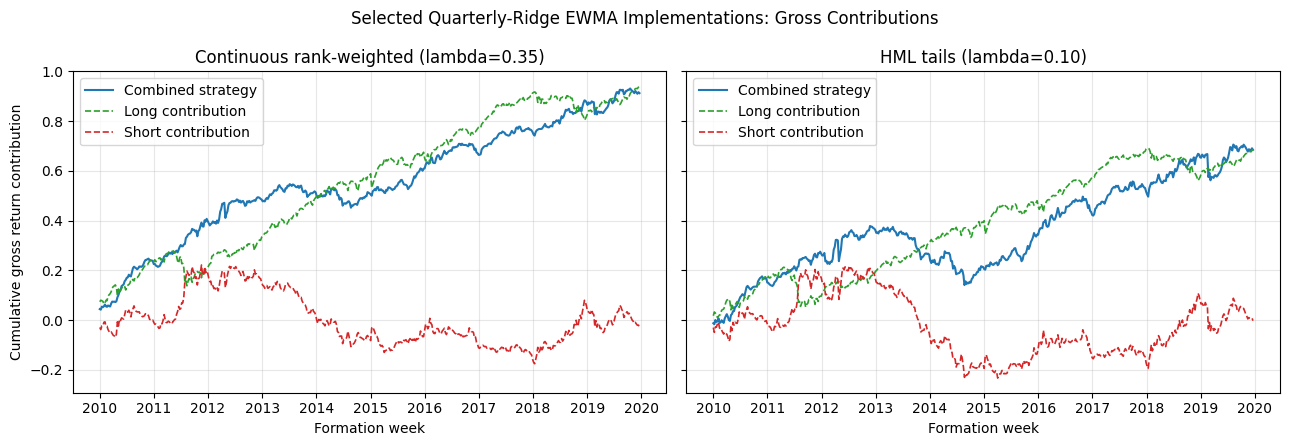

In [38]:
# Gross additive attribution identifies which leg generates the selected payoff.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (strategy, result) in zip(axes, selected_ewma_results.items()):
    cumulative_gross = result["legs"].copy()
    cumulative_gross["Combined strategy"] = cumulative_gross.sum(axis=1)
    cumulative_gross = cumulative_gross.cumsum()
    for component, style in component_styles.items():
        ax.plot(cumulative_gross.index, cumulative_gross[component], label=component, **style)
    ax.set_title(f"{strategy} (lambda={selected_lambdas[strategy]:.2f})")
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Cumulative gross return contribution")
fig.suptitle("Selected Quarterly-Ridge EWMA Implementations: Gross Contributions")
fig.tight_layout()
plt.show()


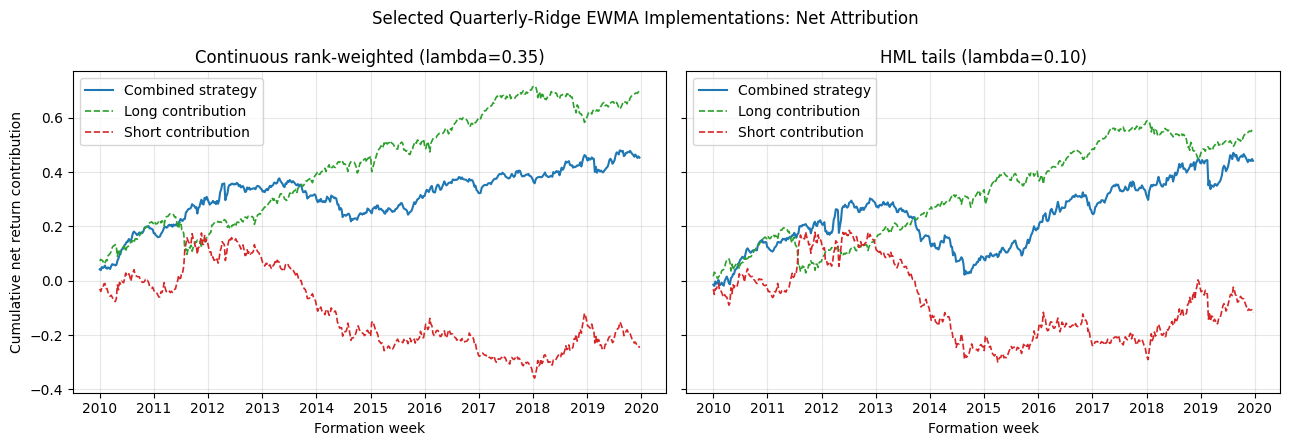

In [39]:
# Net attribution remains additive across the existing contribution legs.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (strategy, net_returns) in zip(axes, selected_ewma_net_returns.items()):
    cumulative_net = net_returns.cumsum()
    for component, style in component_styles.items():
        ax.plot(cumulative_net.index, cumulative_net[component], label=component, **style)
    ax.set_title(f"{strategy} (lambda={selected_lambdas[strategy]:.2f})")
    ax.set_xlabel("Formation week")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Cumulative net return contribution")
fig.suptitle("Selected Quarterly-Ridge EWMA Implementations: Net Attribution")
fig.tight_layout()
plt.show()


### Selected EWMA Interpretation

The continuous portfolio can react more quickly because Ridge distributes information across the full ranking. The top-tail portfolio requires stronger smoothing because small score changes can replace entire tail constituents.

The selected lambdas govern trading speed only. They do not alter Ridge coefficients, feature definitions, or expected-return views, and they must not be reconsidered after observing final out-of-sample performance.


## Black-Litterman Calibration

Ridge and Black-Litterman have separate responsibilities:

- **Ridge** estimates a cross-sectional predictive score;
- **EWMA** controls the trading speed of direct signal portfolios;
- **Black-Litterman** converts the Ridge long basket into benchmark-aware optimized long-only weights.

For a fully invested signal basket $w^{signal}_t$, development active return is

$$
AR_t
=
R^{signal}_{t+1}-R^{SPI}_{t+1}.
$$

The one-sided basket view is

$$
P_t\mu_t=Q_t,
\qquad
P_t=(w^{signal}_t)^\top,
\qquad
Q_t=P_t\pi_t+\widehat{\alpha},
$$

where $\pi_t$ is the benchmark-implied prior and

$$
\widehat{\alpha}=\mathbb{E}[AR_t].
$$

View uncertainty is deliberately conservative:

$$
\Omega=5\,\operatorname{Var}(AR_t).
$$

The development estimates are:

| Ridge basket | Weekly active view | Newey-West t-statistic | Conservative variance |
| --- | ---: | ---: | ---: |
| Continuous long basket | **0.248%** | 3.77 | 0.00097 |
| Top-tail long basket | **0.334%** | 3.02 | 0.00309 |

The top-tail view has a larger expected premium but substantially greater uncertainty. These quantities are saved for the companion notebook and are not re-estimated from 2020+ returns.


In [40]:
# Calibrate BL views from tradable Ridge long baskets in the development period.
# Shift SPI to the same next-week holding period used by every stock-level realized return.
forward_spi_returns = weekly_spi_returns.shift(-CONFIG.forecast_horizon_weeks)
signal_long_books = {
    "Continuous rank-weighted long basket": filtered_continuous_targets.clip(lower=0.0),
    "Top-tail equal-weighted long basket": filtered_hml_targets.clip(lower=0.0),
}

bl_view_rows = []
for strategy, positive_weights in signal_long_books.items():
    # Renormalize positive signal weights to a fully invested long-only basket for the BL view.
    long_weights = positive_weights.div(
        positive_weights.sum(axis=1).replace(0.0, np.nan),
        axis=0,
    ).dropna(how="all")

    # Align realized stock returns exactly to basket dates and columns before aggregation.
    realized_returns = forward_weekly_returns.reindex(
        index=long_weights.index,
        columns=long_weights.columns,
    ).fillna(0.0)
    signal_return = (long_weights * realized_returns).sum(axis=1)
    # The BL view is an active premium over SPI, not an unconstrained standalone return forecast.
    active_return = signal_return.sub(
        forward_spi_returns.reindex(signal_return.index)
    ).dropna()

    # Estimate view strength with serial-correlation-robust inference and inflate variance conservatively.
    mean_active, active_t = newey_west_mean_test(active_return)
    view_variance = active_return.var()
    bl_view_rows.append(
        pd.Series(
            {
                "Mean weekly active return": mean_active,
                "Annualized active return": mean_active * CONFIG.weeks_per_year,
                "Active-return standard deviation": active_return.std(),
                "Newey-West active-return t-statistic": active_t,
                "View variance": view_variance,
                "Conservative view variance": CONFIG.bl_omega_multiplier * view_variance,
                "Omega multiplier": CONFIG.bl_omega_multiplier,
                "Weeks": len(active_return),
            },
            name=strategy,
        )
    )

bl_view_calibration = pd.DataFrame(bl_view_rows)
display(bl_view_calibration.round(6))

# Serialize every frozen modeling and allocation choice consumed by the OOS notebook.
ridge_calibration = {
    "feature_names": list(RIDGE_FEATURE_NAMES),
    "ridge_alpha": selected_ridge_alpha,
    "training_window_weeks": CONFIG.ridge_training_window_weeks,
    "retrain_every_weeks": CONFIG.ridge_retrain_every_weeks,
    "continuous_ewma_lambda": selected_lambdas["Continuous rank-weighted"],
    "tail_ewma_lambda": selected_lambdas["HML tails"],
    "bl_continuous_view_return": float(
        bl_view_calibration.loc[
            "Continuous rank-weighted long basket", "Mean weekly active return"
        ]
    ),
    "bl_continuous_view_variance": float(
        bl_view_calibration.loc[
            "Continuous rank-weighted long basket", "Conservative view variance"
        ]
    ),
    "bl_tail_view_return": float(
        bl_view_calibration.loc[
            "Top-tail equal-weighted long basket", "Mean weekly active return"
        ]
    ),
    "bl_tail_view_variance": float(
        bl_view_calibration.loc[
            "Top-tail equal-weighted long basket", "Conservative view variance"
        ]
    ),
}
# Writing one JSON artifact prevents the backtest from reselecting parameters on 2020+ outcomes.
CONFIG.calibration_path.write_text(
    json.dumps(ridge_calibration, indent=2),
    encoding="utf-8",
)
display(pd.Series(ridge_calibration, name="Frozen Ridge calibration"))


,Mean weekly active return,Annualized active return,Active-return standard deviation,Newey-West active-return t-statistic,View variance,Conservative view variance,Omega multiplier,Weeks
Continuous rank-weighted long basket,0.0025,0.1291,0.0139,3.7718,0.0002,0.0010,5.0000,521.0000
Top-tail equal-weighted long basket,0.0033,0.1735,0.0249,3.0230,0.0006,0.0031,5.0000,521.0000


feature_names                  [vol_scaled_reversal, raw_reversal, residual_v...
ridge_alpha                                                           1,000.0000
training_window_weeks                                                        156
retrain_every_weeks                                                           13
continuous_ewma_lambda                                                    0.3500
tail_ewma_lambda                                                          0.1000
bl_continuous_view_return                                                 0.0025
bl_continuous_view_variance                                               0.0010
bl_tail_view_return                                                       0.0033
bl_tail_view_variance                                                     0.0031
Name: Frozen Ridge calibration, dtype: object

## Frozen Decisions For The OOS Backtest

The development process is now complete. The following specification is passed unchanged to the companion notebook:

| Component | Frozen choice |
| --- | --- |
| Economic hypothesis | Weekly volatility-scaled mean reversion |
| Ridge features | Reversal, residual reversal, volatility, liquidity, value, quality, momentum |
| Ridge target | Centered next-week cross-sectional return rank |
| Feature preprocessing | Weekly 1%-99% winsorization and cross-sectional z-score |
| JKP alignment | Point-in-time carry-forward, maximum 12 monthly observations |
| Ridge training window | 156 weeks |
| Ridge refit frequency | Every 13 weeks |
| Label embargo | Most recent unavailable next-week label excluded |
| Selected Ridge penalty | $\alpha=1{,}000$ |
| Tradability screen | CHF 100,000 median traded value and maximum 10-day zero-volume gap |
| Continuous EWMA speed | $\lambda=0.35$ |
| Top-tail EWMA speed | $\lambda=0.10$ |
| Continuous BL view | Return 0.0024825; variance 0.0009669 |
| Top-tail BL view | Return 0.0033369; variance 0.0030932 |
| Variable transaction cost | 0.2% per unit traded |
| Fixed implementation cost | 1% annually |
| Final evaluation period | January 2020 onward |

### Final Development Conclusion

Ridge improves the development-sample predictive ranking relative to volatility-scaled reversal, particularly across the full continuous cross-section. The advantage remains after applying identical tradability filters. The extreme top-tail improvement is smaller, and the short contribution is not sufficiently reliable to motivate a final market-neutral strategy.

The investable conclusion is therefore cautious and specific: use Ridge to rank tradable stocks, retain the high-score long basket, control turnover with development-selected EWMA speeds, and use Black-Litterman as an optional benchmark-aware risk-allocation layer.

These results are research and calibration evidence, not final performance. The companion notebook must load the saved calibration and evaluate the frozen strategy from 2020 onward without changing alpha, features, lambdas, or BL views.
